*NOTE*: notebook generated by Claude

# rsds low-thresholding — global comparison: `darkday-threshold-rsds-qdm` vs `pr-638-global`

Compares two global `CESM2-WACCM` / `rsds` / `QDMSD` runs (historical ensemble member `r3i1p1f1`, SSP245 ensemble member `003` — the only member the candidate has):

| label | branch | store | what it is |
|---|---|---|---|
| `reference` | `pr-638-global` | `s3://carbonplan-srm/scratch/output/qa/CESM2-WACCM-ERA5-global.icechunk` | pre-darkday-threshold production QDMSD |
| `candidate` | `darkday-threshold-rsds-qdm` | `s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk` | candidate dark-day/low-threshold fix in the QDM debiasing step |

**Scope note:** the two branches live on *different* icechunk stores (candidate is on the `snapshot` store, reference on the `output` store) — that's expected, not a mistake, just how these two runs were written. `reference` also has other ensemble members and `g6_1p5k`/`g6_1p5k_end` scenarios that `candidate` doesn't have yet; this notebook restricts everything to the one historical + one SSP245 member both branches share, so every comparison is apples-to-apples.

**Framing note:** unlike the PR #664 disaggregation-only comparison this notebook is modeled on, `darkday-threshold-rsds-qdm` changes the **QDM debiasing step itself** (dark-day/near-zero-climatology thresholding), not just spatial disaggregation. So `debiased_coarse` is **not** expected to be identical between branches here — the section below treats it as a diagnostic diff (magnitude, where it occurs) rather than an identity check.

Checks two outputs per branch/scenario: the final downscaled (fine ERA5 grid) output, and the pre-disaggregation `debiased_coarse` output (native GCM grid). **Leaf availability is checked at run time** and every section skips/labels branches or scenarios that are missing the data a given check needs rather than failing.


In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import catalog
from srm.config import _icechunk_storage_for_path
from srm.downscaling_utils import interpolate_coarse_to_fine_grid
from srm.qa_flags import (
    DIR_QA_FLAG_CONSTANT_INPUTS,
    SCENARIO_COMPARISONS,
    TREND_VARIABLE_SETTINGS,
    calculate_ensemble_mean_deltas,
    calculate_thresholds,
    flag_global_exceedances,
    flag_outliers,
    flag_rsds_above_max,
    plot_flags,
)
from srm.qaqc import area_weights, calculate_distortion_flags, sign_flip_mask

## Coiled cluster

Global x fine-grid (721x1440) x full historical (1978-2014) + SSP245 (2015-2099) reads across two branches and several checks -- worth a cluster rather than a local read, same as the PR #664 global comparison this is modeled on.


In [ ]:
import coiled
from frisky import hijack

cluster = coiled.Cluster(
    name="srm-darkday-rsds-comparison",
    region="us-west-2",
    n_workers=8,
    worker_vm_types=["m8gn.xlarge"],
    scheduler_vm_types="c8g.xlarge",
    spot_policy="spot_with_fallback",
    use_best_zone=True,
    tags={"Project": "SRM"},
    worker_options={"nthreads": 8},
    environ={"ZARR_ASYNC__CONCURRENCY": "128"},
)
client = hijack(cluster.get_client())
client

[2026-09-04 09:19:50,008][INFO    ][coiled] Fetching latest package priorities...
[2026-09-04 09:19:50,009][INFO    ][coiled.package_sync] Resolving your local /Users/clairezarakas/Documents/science/srm-downscaling/uv.lock Python environment...
[2026-09-04 09:19:50,863][INFO    ][coiled.package_sync] Scanning 293 python packages...
[2026-09-04 09:19:51,223][INFO    ][coiled] Running pip check...
[2026-09-04 09:19:51,664][INFO    ][coiled] Validating environment...
[2026-09-04 09:19:52,499][INFO    ][coiled] Creating wheel for ~/Documents/science/srm-downscaling/src...
[2026-09-04 09:19:52,614][INFO    ][coiled] Creating wheel for srm...
[2026-09-04 09:19:55,281][INFO    ][coiled] Uploading coiled_local_src...
[2026-09-04 09:19:56,440][INFO    ][coiled] Uploading srm...
[2026-09-04 09:19:57,407][INFO    ][coiled] Creating software environment...
[2026-09-04 09:19:58,473][INFO    ][coiled] Creating Cluster (name: srm-darkday-rsds-comparison, https://cloud.coiled.io/clusters/2005885 ). Th

<frisky.Client: scheduler="wss://cluster-eglao.dask.host/evrmEaCgFHFCaixI/frisky-comm?__frisky_dial_host=52.33.36.19" id="client-0">

2026-09-04 10:01:40,184 - distributed.batched - INFO - Batched Comm Closed <TLS (closed) Client->Scheduler local=tls://192.168.4.27:62179 remote=tls://52.33.36.19:443>
Traceback (most recent call last):
  File "/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/distributed/batched.py", line 115, in _background_send
    nbytes = yield coro
             ^^^^^^^^^^
  File "/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/tornado/gen.py", line 783, in run
    value = future.result()
  File "/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/distributed/comm/tcp.py", line 263, in write
    raise CommClosedError()
distributed.comm.core.CommClosedError


In [5]:
# --- Run parameters --------------------------------------------------------
GCM = "CESM2-WACCM"
VAR = "rsds"
METHOD = "qdmsd"

STORES = {
    "reference": "s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk",
    "candidate": "s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk",
}

BRANCHES = {
    "reference": "main-cf075f1-sep3",
    "candidate": "pr669-threshold-historical-test001",
}

LABELS = list(BRANCHES)  # ["reference", "candidate"]

# Ensemble-member id format differs by scenario in this pipeline: historical leaves are
# keyed by CMIP6 variant id, SSP245 leaves by the pipeline's own zero-padded member number.
# These are the only members `candidate` has, so `reference` is restricted to match.
ENSEMBLE_BY_SCENARIO = {"historical": "r3i1p1f1", "ssp245": "003"}
SCENARIOS = ["historical", "ssp245"]

## Open each branch and discover what's actually there

In [6]:
repos = {
    label: icechunk.Repository.open(_icechunk_storage_for_path(STORES[label])) for label in LABELS
}

trees = {}
for label in LABELS:
    session = repos[label].readonly_session(branch=BRANCHES[label])
    trees[label] = xr.open_datatree(session.store, engine="zarr", consolidated=False, chunks="auto")

In [7]:
SOURCES = ["downscaled", "debiased_coarse"]


def leaf_path(scenario: str, debiased_coarse: bool = False) -> str:
    ens = ENSEMBLE_BY_SCENARIO[scenario]
    prefix = f"{METHOD}/debiased_coarse/{scenario}" if debiased_coarse else f"{METHOD}/{scenario}"
    return f"{prefix}/{VAR}/{ens}"


def has_leaf(tree: xr.DataTree, path: str) -> bool:
    try:
        node = tree[path]
    except KeyError:
        return False
    return VAR in node.dataset.data_vars


availability = {
    label: {
        scenario: {
            source: has_leaf(
                trees[label], leaf_path(scenario, debiased_coarse=(source == "debiased_coarse"))
            )
            for source in SOURCES
        }
        for scenario in SCENARIOS
    }
    for label in LABELS
}

In [8]:
pd.DataFrame(
    {
        (label, source): {scenario: availability[label][scenario][source] for scenario in SCENARIOS}
        for label in LABELS
        for source in SOURCES
    }
).T

historical  ssp245
reference downscaled             True    True
          debiased_coarse        True    True
candidate downscaled             True    True
          debiased_coarse        True    True

In [9]:
# (label, scenario) -> DataArray, only for leaves that actually exist
data = {
    (label, scenario): trees[label][leaf_path(scenario)].dataset[VAR]
    for label in LABELS
    for scenario in SCENARIOS
    if availability[label][scenario]["downscaled"]
}

# Same, but the pre-disaggregation debiased_coarse output on the native GCM grid. Since
# darkday-threshold-rsds-qdm changes the debiasing step itself, these are NOT expected to be
# identical between branches -- see the diagnostic-diff section below rather than a sanity assert.
data_coarse = {
    (label, scenario): trees[label][leaf_path(scenario, debiased_coarse=True)].dataset[VAR]
    for label in LABELS
    for scenario in SCENARIOS
    if availability[label][scenario]["debiased_coarse"]
}

sorted(data.keys()), sorted(data_coarse.keys())

([('candidate', 'historical'),
  ('candidate', 'ssp245'),
  ('reference', 'historical'),
  ('reference', 'ssp245')],
 [('candidate', 'historical'),
  ('candidate', 'ssp245'),
  ('reference', 'historical'),
  ('reference', 'ssp245')])

# Look at data for comparison

In [10]:
data_ref_hist = data[("reference", "historical")].mean(dim="time").load()
data_ref_ssp245 = data[("reference", "ssp245")].mean(dim="time").load()

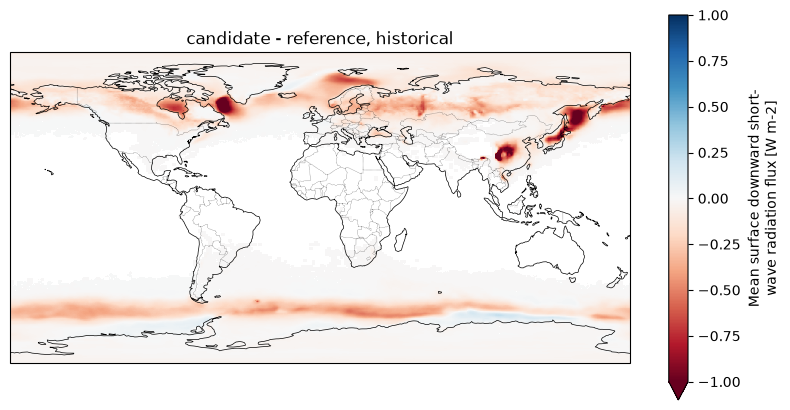

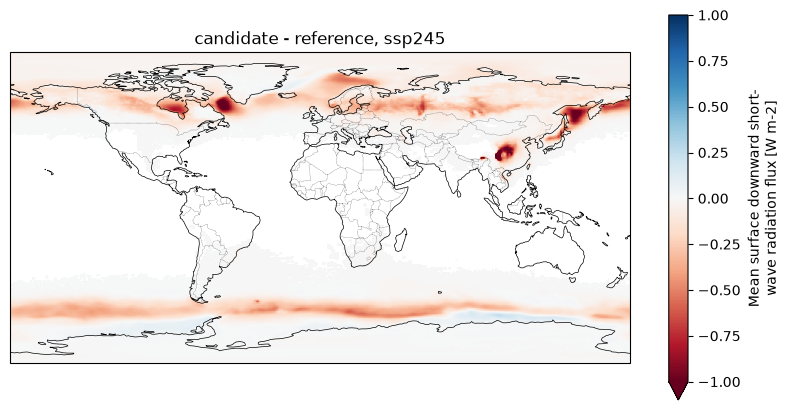

In [11]:
for scenario in SCENARIOS:
    if ("candidate", scenario) not in data:
        print(f"skipping {scenario}: candidate downscaled output missing")
        continue
    comp_mean = data[("candidate", scenario)].mean(dim="time")
    ref_mean = data_ref_hist if scenario == "historical" else data_ref_ssp245
    delta = comp_mean - ref_mean

    fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))
    delta.where(np.abs(delta) > 0).plot(
        ax=ax, transform=ccrs.PlateCarree(), vmax=1, vmin=-1, cmap=plt.cm.RdBu
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.set_title(f"candidate - reference, {scenario}")
    plt.show()

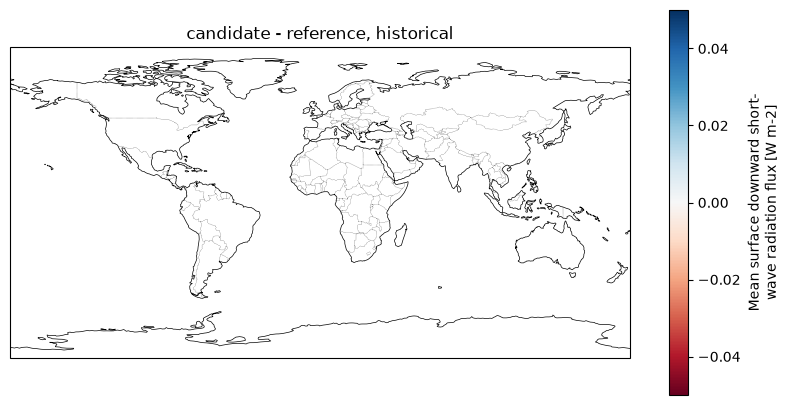

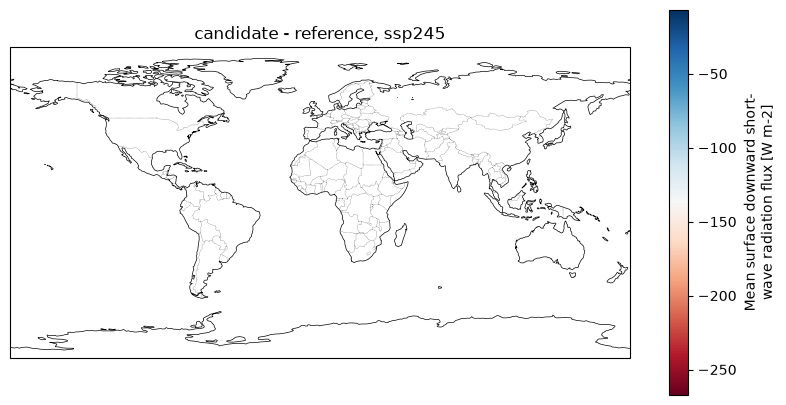

In [12]:
data_ref_hist_max = data[("reference", "historical")].max(dim="time").load()
data_ref_ssp245_max = data[("reference", "ssp245")].max(dim="time").load()

for scenario in SCENARIOS:
    if ("candidate", scenario) not in data:
        print(f"skipping {scenario}: candidate downscaled output missing")
        continue
    comp_max = data[("candidate", scenario)].max(dim="time")
    ref_max = data_ref_hist_max if scenario == "historical" else data_ref_ssp245_max
    delta = comp_max - ref_max

    fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))
    delta.where(np.abs(delta) > 0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.set_title(f"candidate - reference, {scenario}")
    plt.show()

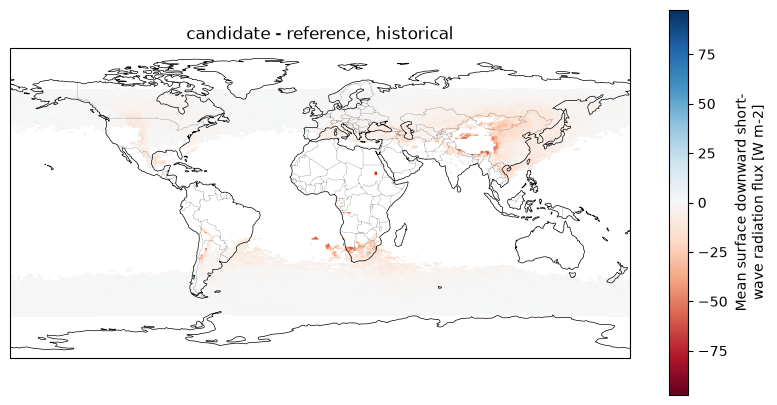

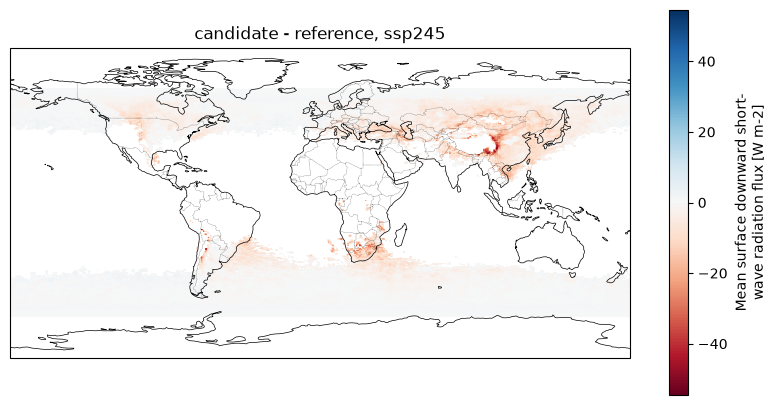

In [13]:
data_ref_hist_min = data[("reference", "historical")].min(dim="time").load()
data_ref_ssp245_min = data[("reference", "ssp245")].min(dim="time").load()

for scenario in SCENARIOS:
    if ("candidate", scenario) not in data:
        print(f"skipping {scenario}: candidate downscaled output missing")
        continue
    comp_min = data[("candidate", scenario)].min(dim="time")
    ref_min = data_ref_hist_min if scenario == "historical" else data_ref_ssp245_min
    delta = comp_min - ref_min

    fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))
    delta.where(np.abs(delta) > 0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.set_title(f"candidate - reference, {scenario}")
    plt.show()

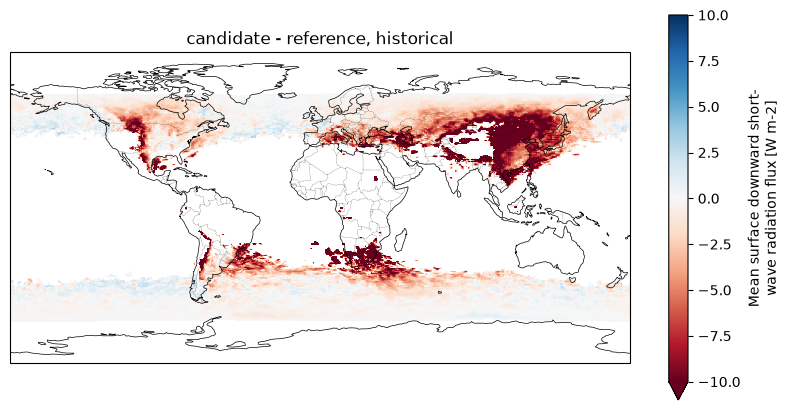

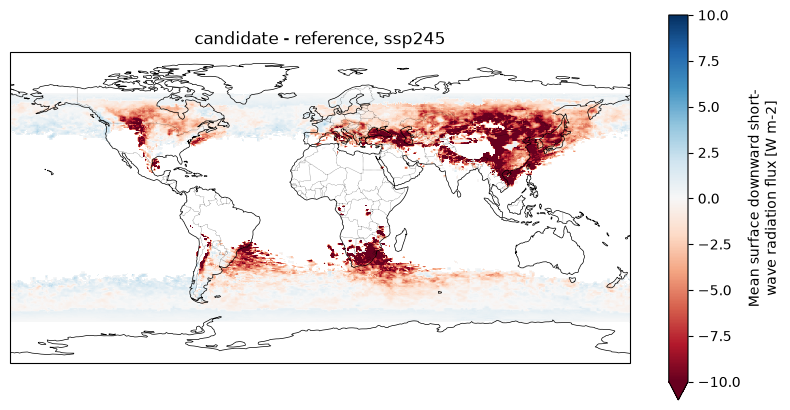

In [15]:
data_ref_hist_min = data[("reference", "historical")].min(dim="time").load()
data_ref_ssp245_min = data[("reference", "ssp245")].min(dim="time").load()

for scenario in SCENARIOS:
    if ("candidate", scenario) not in data:
        print(f"skipping {scenario}: candidate downscaled output missing")
        continue
    comp_min = data[("candidate", scenario)].min(dim="time")
    ref_min = data_ref_hist_min if scenario == "historical" else data_ref_ssp245_min
    delta = comp_min - ref_min

    fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))
    delta.where(np.abs(delta) > 0).plot(
        ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu, vmax=10, vmin=-10
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.set_title(f"candidate - reference, {scenario}")
    plt.show()

## Debiased_coarse: diagnostic diff (not an identity check)

`darkday-threshold-rsds-qdm` changes the QDM debiasing step's handling of near-zero-climatology ("dark day") values, so `debiased_coarse` -- written *before* spatial disaggregation -- can legitimately differ between branches here. Unlike the PR #664 comparison this notebook is modeled on (which asserted `debiased_coarse` identity because that fix only touched disaggregation), this section just characterizes the diff: how big it is, and where it occurs. A diff concentrated at high latitudes / low-rsds cells is consistent with the fix doing what it's supposed to; a diff that shows up broadly (e.g. mid-latitude, high-rsds cells) would be a sign the threshold change is reaching further than intended.


historical: max abs diff = 1.316e+02, mean abs diff = 6.230e-02


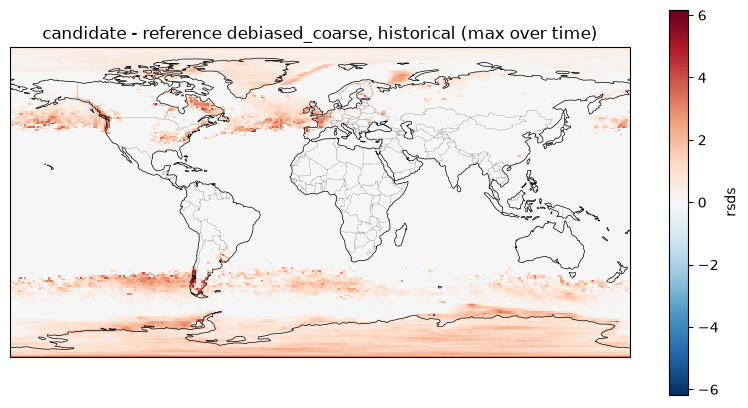

ssp245: max abs diff = 1.278e+03, mean abs diff = 5.372e-02


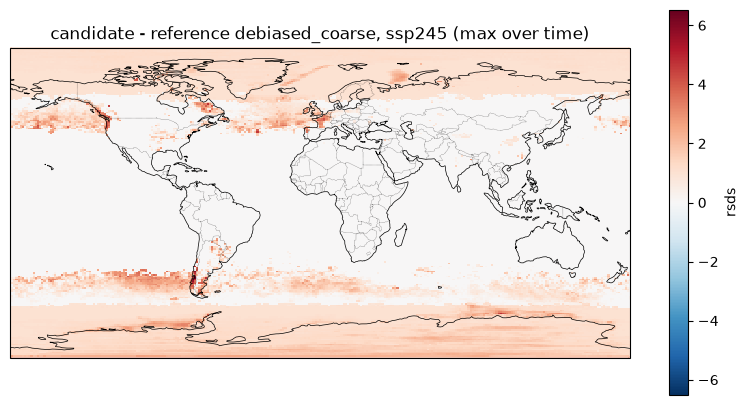

In [16]:
debiased_coarse_diag = {}
for scenario in SCENARIOS:
    if ("reference", scenario) not in data_coarse or ("candidate", scenario) not in data_coarse:
        print(f"skipping {scenario}: debiased_coarse missing on one or both branches")
        continue
    diff = data_coarse[("candidate", scenario)] - data_coarse[("reference", scenario)]
    max_abs_diff = float(np.abs(diff).max().compute())
    mean_abs_diff = float(np.abs(diff).mean().compute())
    frac_nonzero = float((np.abs(diff) > 0).mean().compute())
    debiased_coarse_diag[scenario] = {
        "max_abs_diff": max_abs_diff,
        "mean_abs_diff": mean_abs_diff,
        "frac_cells_days_changed": frac_nonzero,
    }
    print(f"{scenario}: max abs diff = {max_abs_diff:.3e}, mean abs diff = {mean_abs_diff:.3e}")

    fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))
    diff.max(dim="time").plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu_r, center=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
    ax.set_title(f"candidate - reference debiased_coarse, {scenario} (max over time)")
    plt.show()

In [17]:
debiased_coarse_summary = pd.DataFrame(debiased_coarse_diag).T
debiased_coarse_summary

,max_abs_diff,mean_abs_diff,frac_cells_days_changed
historical,131.561829,0.062297,0.130342
ssp245,1277.659546,0.053719,0.047015


## Shared helpers: area-weighted flag summaries

`trend_distortion`/`flipped_sign` (Evaluation 3) are time-invariant already (2D, no `time` dim) — `summarize_flag` handles those directly. Every other check here (`rsds_max_exceeded`, `annual_outlier_flag`, `outside_global_plausible_range`) is time-varying, but nothing downstream ever needs a single day's value: the plots are always a time-aggregate map and the summary stats are always totals/fractions over all time. So each of those is reduced over `time` **once** right after it's computed, and both the plot and `summarize_flag_count` reuse that one small 2D count.


In [18]:
def summarize_flag(flag: xr.DataArray) -> dict:
    """For time-invariant (already 2D) flags -- trend_distortion/flipped_sign."""
    weights = area_weights(flag["lat"])
    flagged = int(flag.sum().compute())
    pct_flagged = 100 * flagged / flag.size
    area_weighted_pct = 100 * float(flag.astype("float64").weighted(weights).mean().compute())
    return {
        "flagged_cells": flagged,
        "pct_flagged": pct_flagged,
        "area_weighted_pct": area_weighted_pct,
    }


def summarize_flag_count(count: xr.DataArray, n_time: int) -> dict:
    """For time-varying flags, given a per-pixel day count (flag.sum(dim='time'), already
    computed once) and the number of days it was summed over -- avoids re-touching the full
    per-day array a second time just to get summary stats.
    """
    weights = area_weights(count["lat"])
    flagged = int(count.sum().compute())
    pct_flagged = 100 * flagged / (count.size * n_time)
    frac_flagged = count / n_time
    area_weighted_pct = 100 * float(frac_flagged.weighted(weights).mean().compute())
    return {
        "flagged_pixel_days": flagged,
        "pct_flagged": pct_flagged,
        "area_weighted_pct": area_weighted_pct,
    }

## Evaluation 1: unrealistic rsds values (zonal day-of-year max)

`flag_rsds_above_max` against the cached `zonal_doy_max_rsds` ceiling built in `flag_step1_produce-datasets-for-qa-flags.ipynb` (max downwelling solar radiation across all longitudes in a latitude band, unioned across ERA5 and three GCMs' historical/g6/ssp245 scenarios). This only checks the high side and only applies to `data` (the fine-resolution downscaled output) -- this ceiling is defined on ERA5's fine grid, not `data_coarse`'s native GCM grid.


In [19]:
zonal_doy_max_rsds = xr.open_zarr(
    DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr", group="zonal_doy_max_rsds"
)["data"].load()

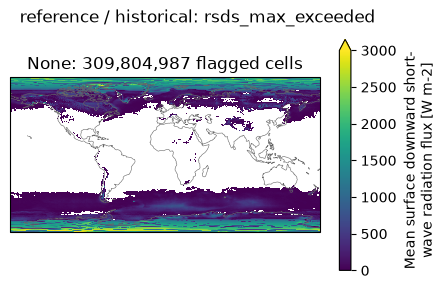

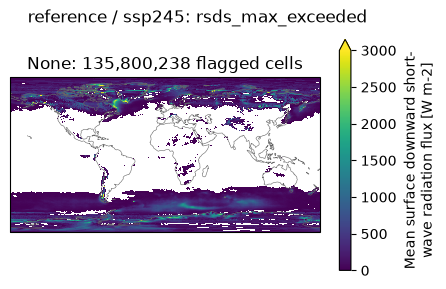

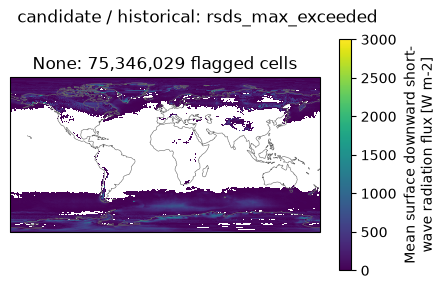

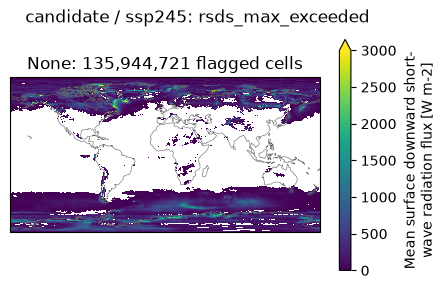

In [20]:
rsds_max_exceeded = {}
for (label, scenario), da in data.items():
    flag = flag_rsds_above_max(da, zonal_doy_max_rsds=zonal_doy_max_rsds)
    flag_count = flag.sum(dim="time").load()
    rsds_max_exceeded[(label, scenario)] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False, vlims=[0, 3000])
    plt.suptitle(f"{label} / {scenario}: rsds_max_exceeded")
    plt.show()

In [21]:
rsds_max_summary = pd.DataFrame(
    {
        f"{label}/{scenario}": summarize_flag_count(
            count, n_time=data[(label, scenario)].sizes["time"]
        )
        for (label, scenario), count in rsds_max_exceeded.items()
    }
).T
rsds_max_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
reference/historical,309804987.0,2.208039,0.581091
reference/ssp245,135800238.0,0.421305,0.226686
candidate/historical,75346029.0,0.537005,0.275055
candidate/ssp245,135944721.0,0.421754,0.226417


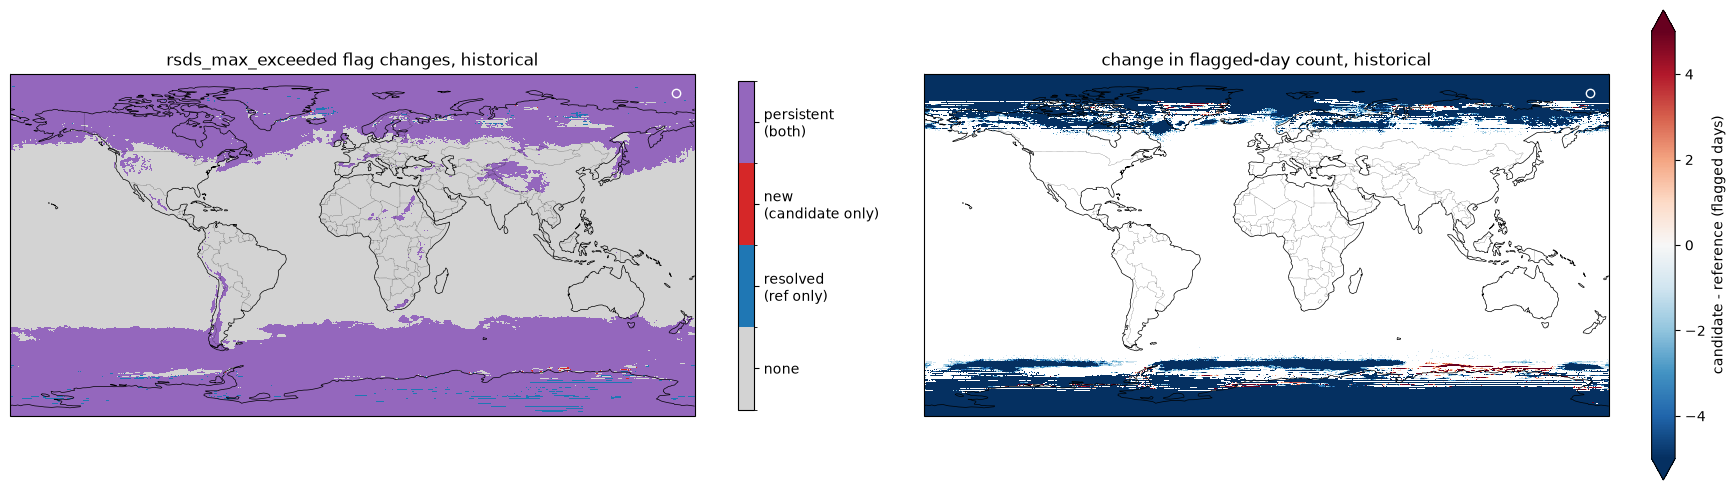

historical: new=207 resolved=5777 persistent=495706


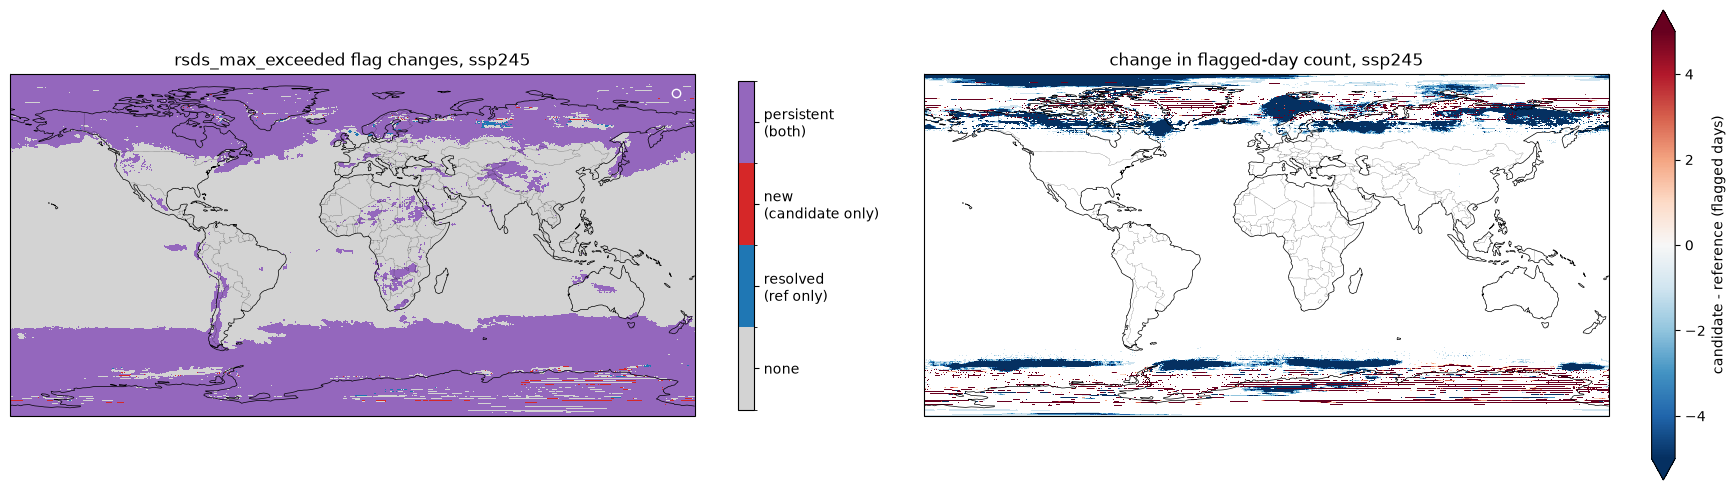

ssp245: new=1792 resolved=1389 persistent=497114


In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

for scenario in SCENARIOS:
    if ("reference", scenario) not in rsds_max_exceeded or (
        "candidate",
        scenario,
    ) not in rsds_max_exceeded:
        continue

    ref_count = rsds_max_exceeded[("reference", scenario)]
    cand_count = rsds_max_exceeded[("candidate", scenario)]

    ref_flagged = ref_count > 0
    cand_flagged = cand_count > 0

    new_flags = cand_flagged & ~ref_flagged
    resolved_flags = ref_flagged & ~cand_flagged
    persistent_flags = ref_flagged & cand_flagged

    # 0 = never flagged, 1 = resolved (ref only), 2 = new (candidate only), 3 = persistent (both)
    category = xr.zeros_like(ref_flagged, dtype="int8")
    category = category.where(~resolved_flags, 1)
    category = category.where(~new_flags, 2)
    category = category.where(~persistent_flags, 3)

    delta = cand_count - ref_count

    fig, axes = plt.subplots(1, 2, figsize=(18, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))

    cmap_cat = mcolors.ListedColormap(["lightgrey", "tab:blue", "tab:red", "tab:purple"])
    norm_cat = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_cat.N)
    im0 = category.plot(
        ax=axes[0], transform=ccrs.PlateCarree(), cmap=cmap_cat, norm=norm_cat, add_colorbar=False
    )
    cbar0 = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3], shrink=0.7)
    cbar0.ax.set_yticklabels(
        ["none", "resolved\n(ref only)", "new\n(candidate only)", "persistent\n(both)"]
    )
    axes[0].set_title(f"rsds_max_exceeded flag changes, {scenario}")

    delta.where(np.abs(delta) > 0).plot(
        ax=axes[1],
        transform=ccrs.PlateCarree(),
        cmap=plt.cm.RdBu_r,
        vmax=5,
        vmin=-5,
        cbar_kwargs={"label": "candidate - reference (flagged days)"},
    )
    axes[1].set_title(f"change in flagged-day count, {scenario}")

    for ax in axes:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
        ax.plot([170], [80], "ow", fillstyle="none", transform=ccrs.PlateCarree())

    plt.tight_layout()
    plt.show()

    print(
        f"{scenario}: new={int(new_flags.sum())} resolved={int(resolved_flags.sum())} persistent={int(persistent_flags.sum())}"
    )

## Point comparisons: rsds by day-of-year at select locations

`darkday-threshold-rsds-qdm`'s fix targets near-zero-climatology ("dark day" / polar-night) cells, so it should matter most at high latitudes. `85N` is the point most likely to show a visible difference between `reference` and `candidate`; `Beijing`, `Copenhagen`, and `Seattle` are mid-latitude regression checks -- the fix shouldn't visibly perturb rsds there, so a difference at those points would be a red flag rather than the expected signal.

Both scenarios are overlaid at each point (color = scenario, marker = branch) so a shift in the seasonal cycle and a shift between historical/SSP245 periods are both visible in one plot.


In [23]:
POINTS = {
    "Beijing": (40.05, 116.2),
    "Copenhagen": (55.6761, 12.5683),
    "Seattle": (47.6062, -122.3321),
    "85N": (85.0, 0.0),
    "Russia": (61.0, 41.0),
    "Sichuan Basin": (30.6, 103.8),
    "80N": (80.0, 170.0),
}

LABEL_COLORS = {"reference": "tab:blue", "candidate": "tab:orange"}

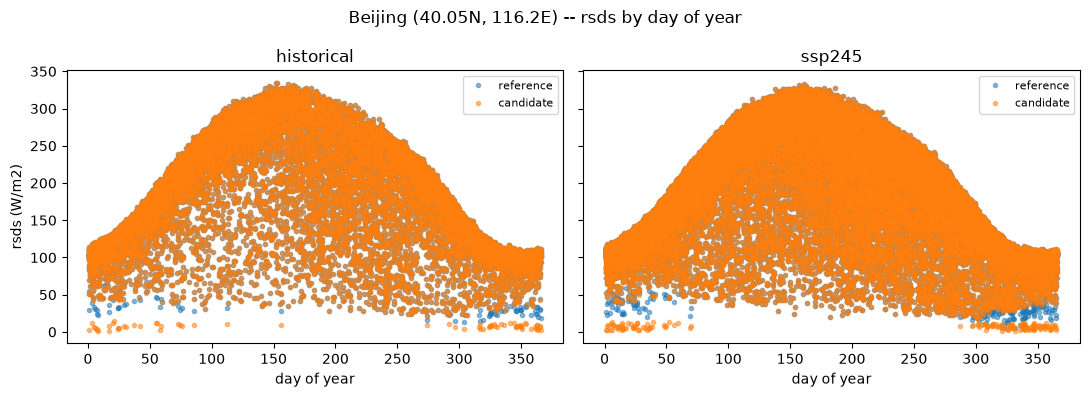

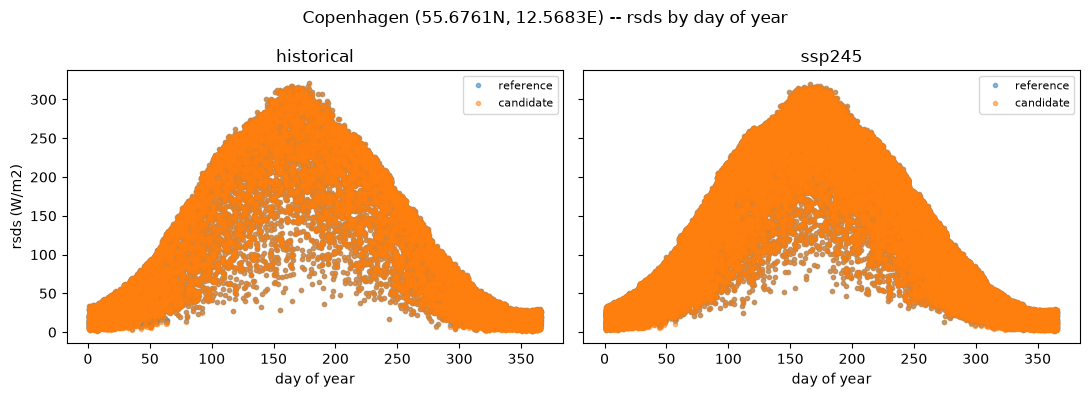

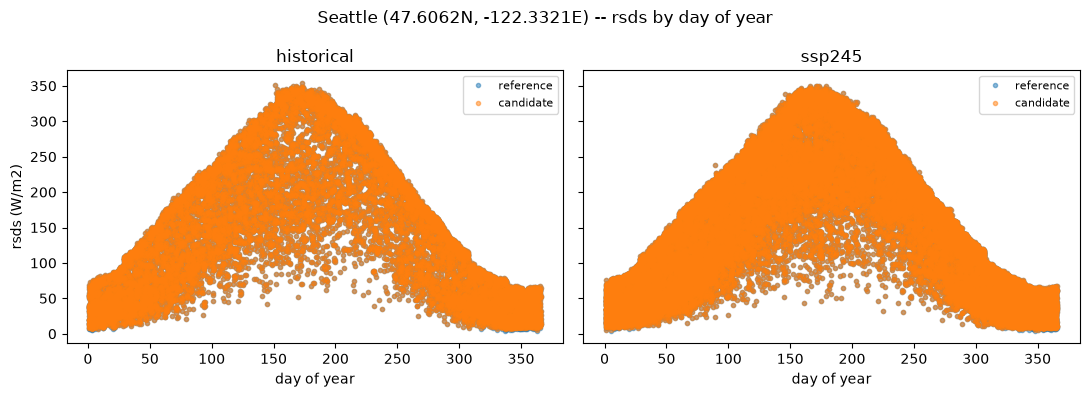

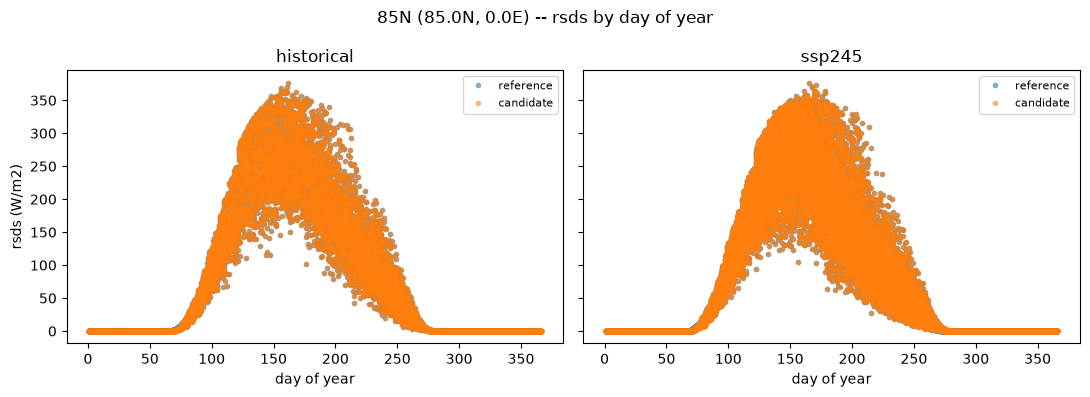

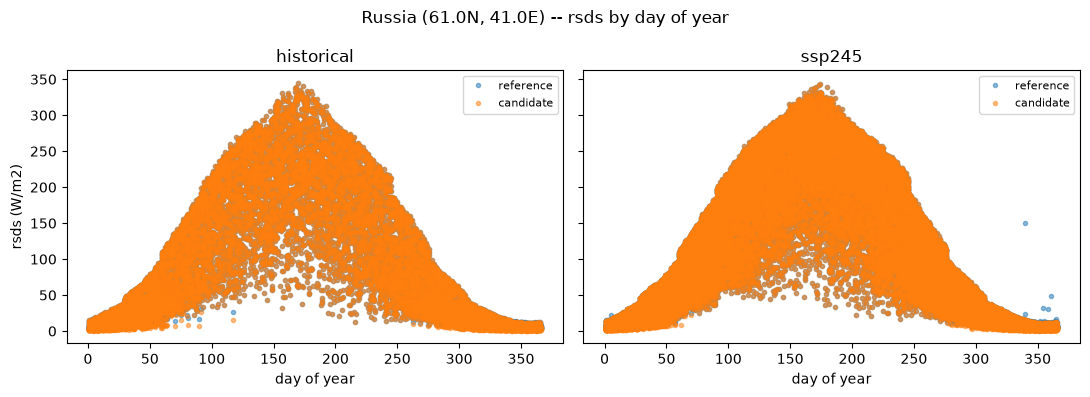

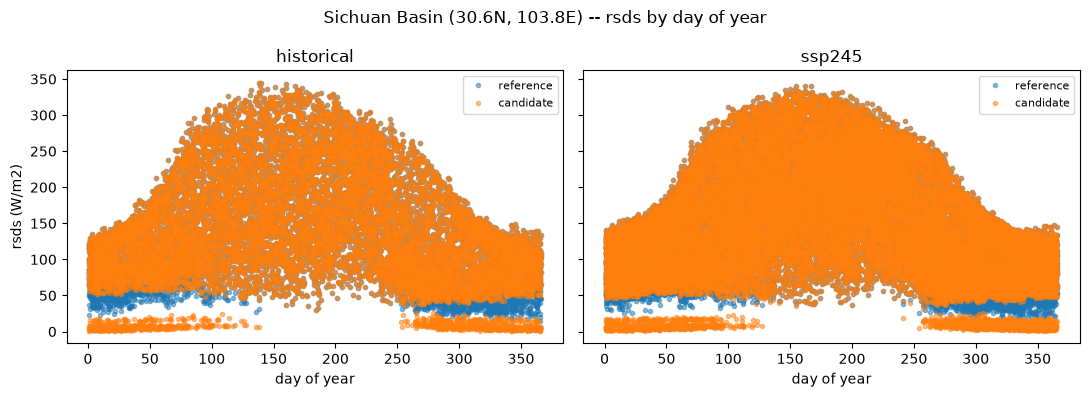

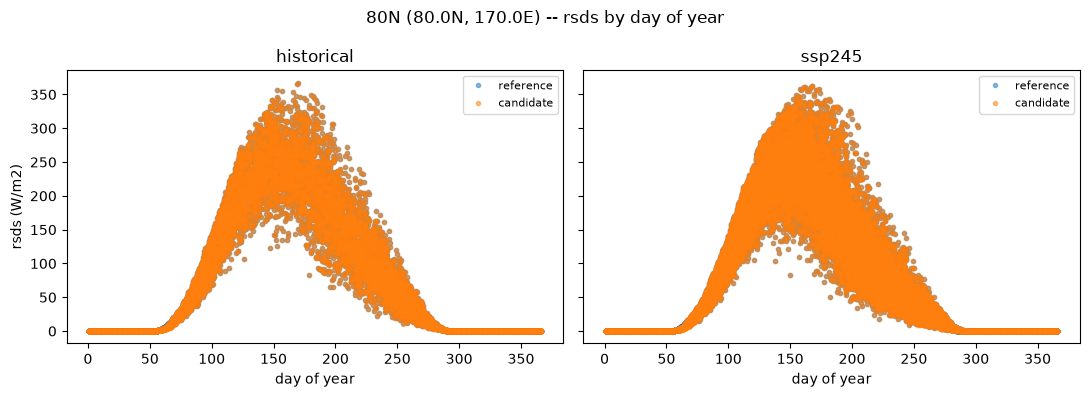

In [29]:
for name, (pt_lat, pt_lon) in POINTS.items():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, scenario in zip(axes, SCENARIOS):
        for label in LABELS:
            if (label, scenario) not in data:
                continue
            da_pt = data[(label, scenario)].sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
            ax.plot(
                da_pt["time.dayofyear"],
                da_pt,
                "o",
                color=LABEL_COLORS[label],
                markersize=3,
                alpha=0.5,
                label=label,
            )
        ax.set_xlabel("day of year")
        ax.set_title(scenario)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("rsds (W/m2)")
    fig.suptitle(f"{name} ({pt_lat}N, {pt_lon}E) -- rsds by day of year")
    plt.tight_layout()
    plt.show()

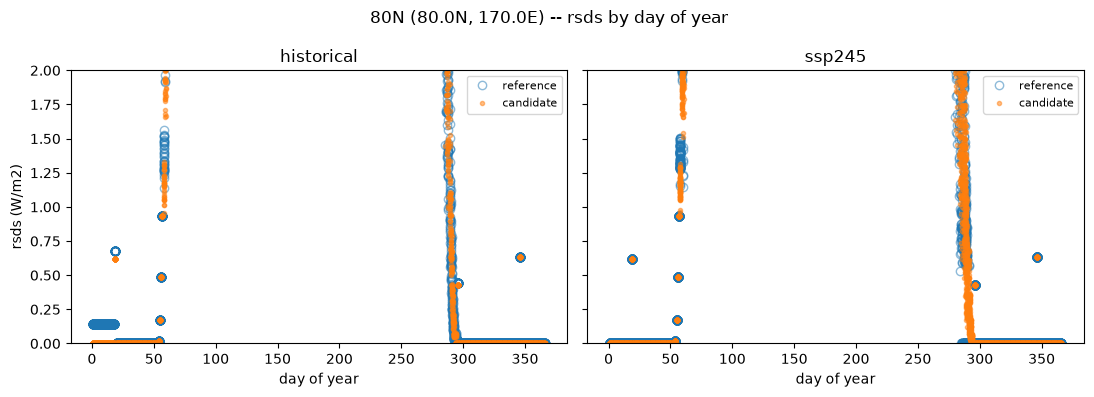

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, scenario in zip(axes, SCENARIOS):
    for label in LABELS:
        if (label, scenario) not in data:
            continue
        da_pt = data[(label, scenario)].sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
        if label == "candidate":
            marker = "."
            fillstyle = "full"
        elif label == "reference":
            marker = "o"
            fillstyle = "none"
        ax.plot(
            da_pt["time.dayofyear"],
            da_pt,
            marker,
            fillstyle=fillstyle,
            color=LABEL_COLORS[label],
            markersize=6,
            alpha=0.5,
            label=label,
        )
    ax.set_xlabel("day of year")
    ax.set_title(scenario)
    ax.legend(fontsize=8)
axes[0].set_ylabel("rsds (W/m2)")
fig.suptitle(f"{name} ({pt_lat}N, {pt_lon}E) -- rsds by day of year")
plt.tight_layout()
plt.ylim([0, 2])
plt.show()

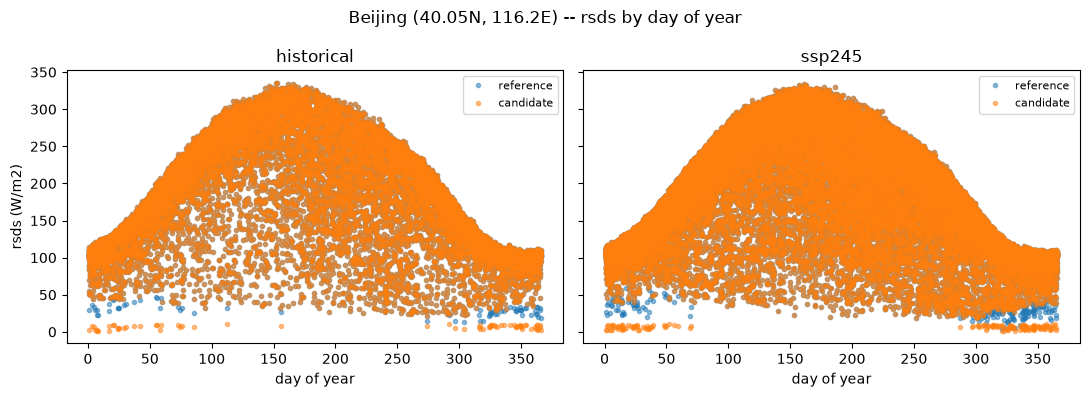

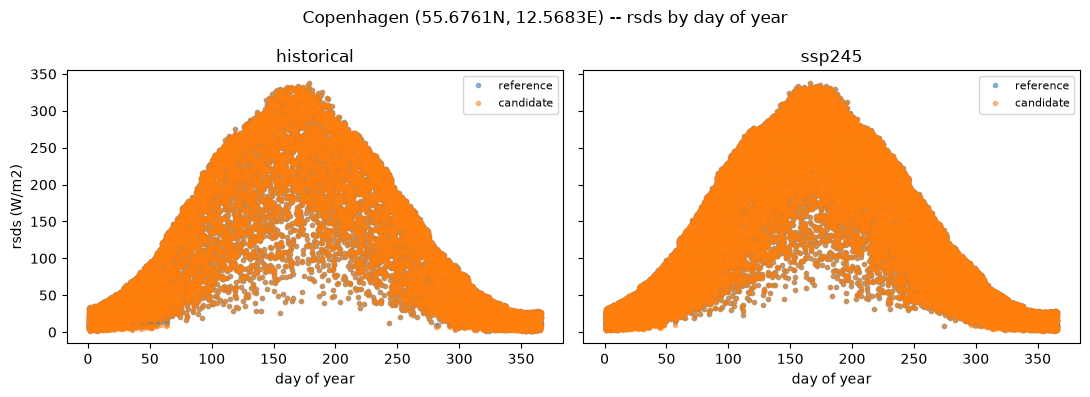

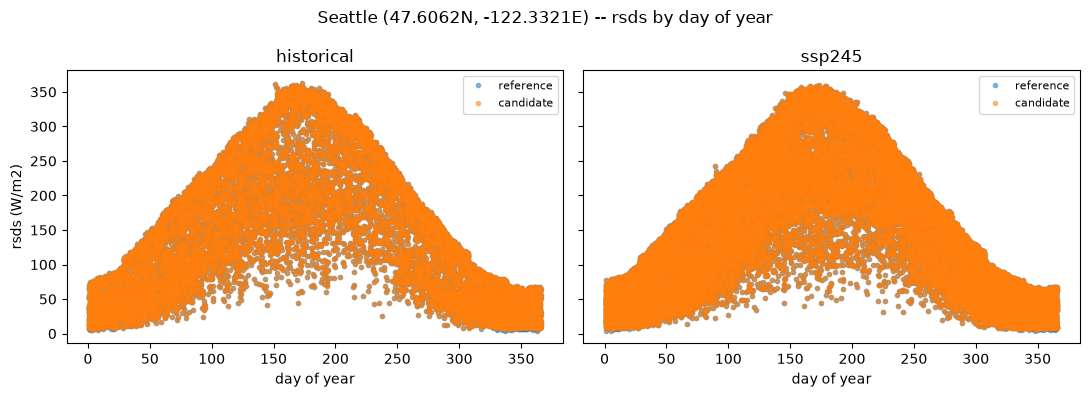

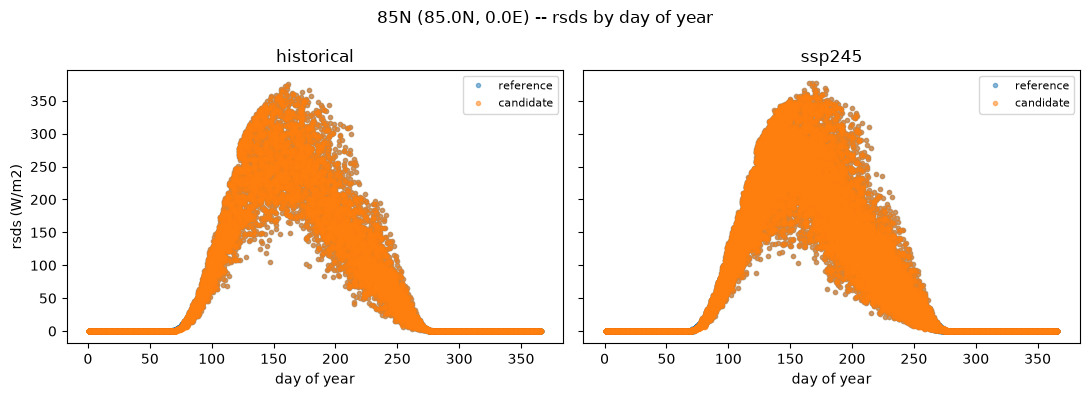

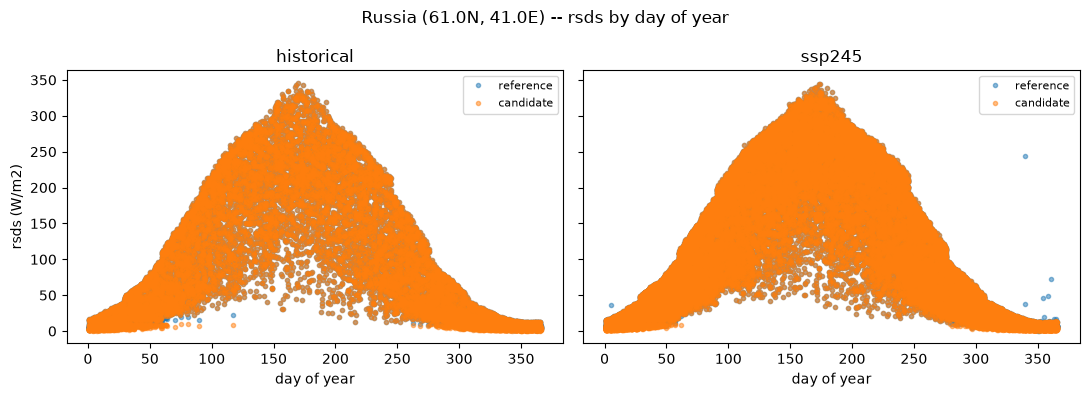

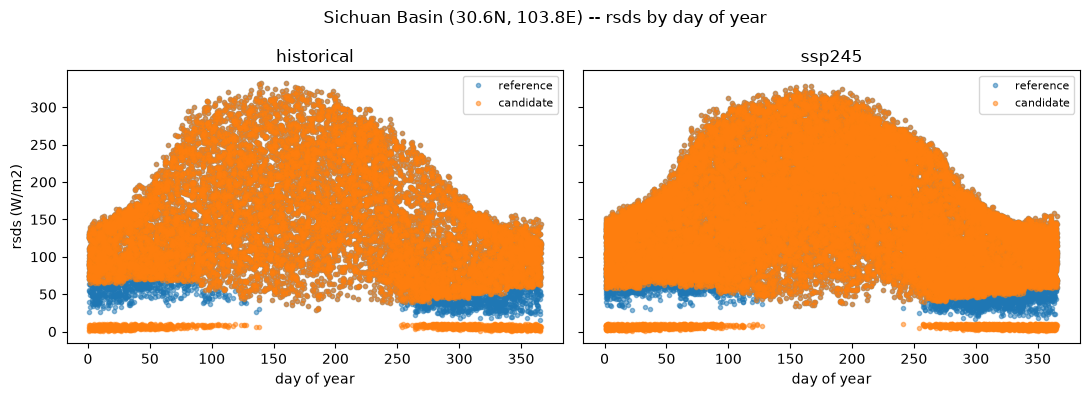

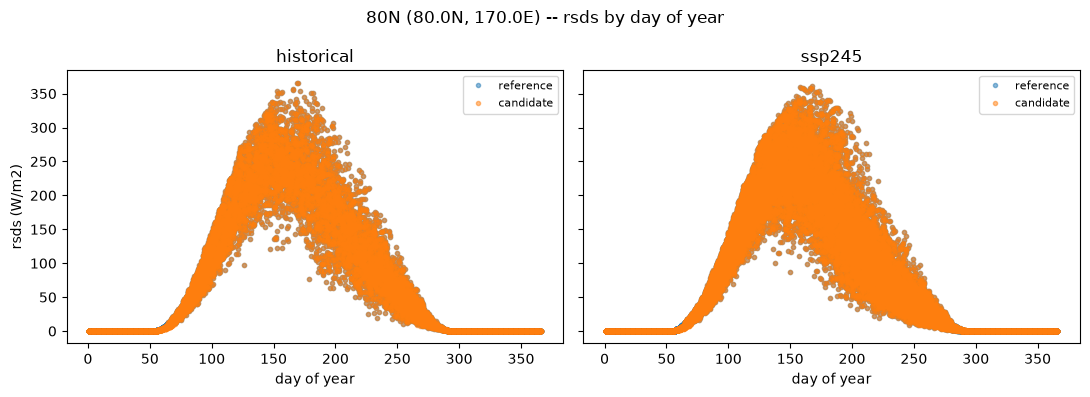

In [33]:
for name, (pt_lat, pt_lon) in POINTS.items():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, scenario in zip(axes, SCENARIOS):
        for label in LABELS:
            if (label, scenario) not in data_coarse:
                continue
            da_pt = (
                data_coarse[(label, scenario)].sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
            )
            ax.plot(
                da_pt["time.dayofyear"],
                da_pt,
                "o",
                color=LABEL_COLORS[label],
                markersize=3,
                alpha=0.5,
                label=label,
            )
        ax.set_xlabel("day of year")
        ax.set_title(scenario)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("rsds (W/m2)")
    fig.suptitle(f"{name} ({pt_lat}N, {pt_lon}E) -- rsds by day of year")
    plt.tight_layout()
    plt.show()

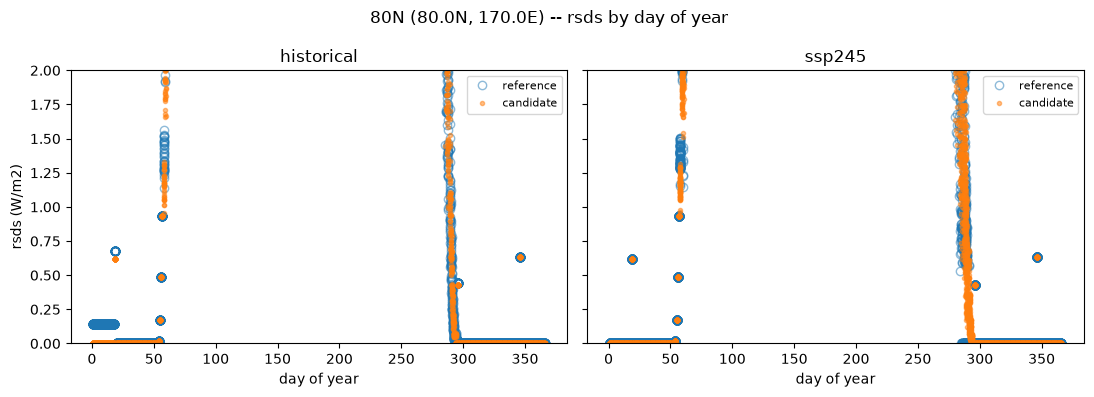

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, scenario in zip(axes, SCENARIOS):
    for label in LABELS:
        if (label, scenario) not in data:
            continue
        da_pt = data[(label, scenario)].sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
        if label == "candidate":
            marker = "."
            fillstyle = "full"
        elif label == "reference":
            marker = "o"
            fillstyle = "none"
        ax.plot(
            da_pt["time.dayofyear"],
            da_pt,
            marker,
            fillstyle=fillstyle,
            color=LABEL_COLORS[label],
            markersize=6,
            alpha=0.5,
            label=label,
        )
    ax.set_xlabel("day of year")
    ax.set_title(scenario)
    ax.legend(fontsize=8)
axes[0].set_ylabel("rsds (W/m2)")
fig.suptitle(f"{name} ({pt_lat}N, {pt_lon}E) -- rsds by day of year")
plt.tight_layout()
plt.ylim([0, 2])
plt.show()

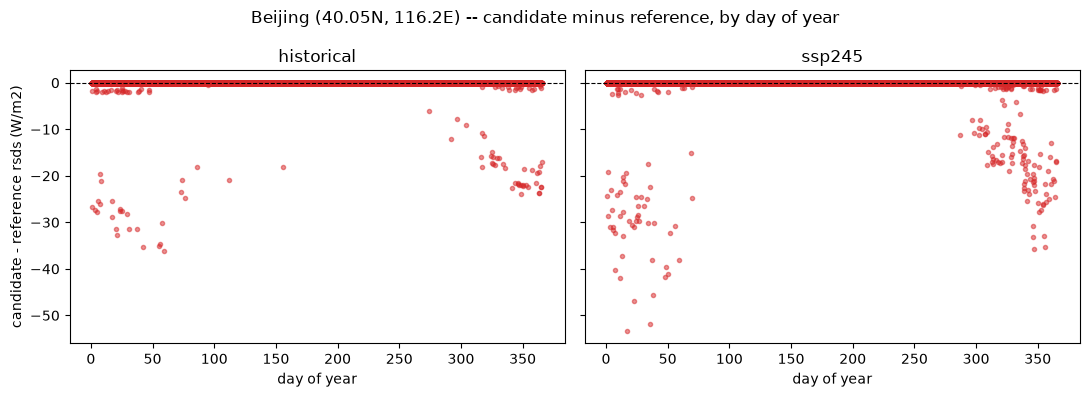

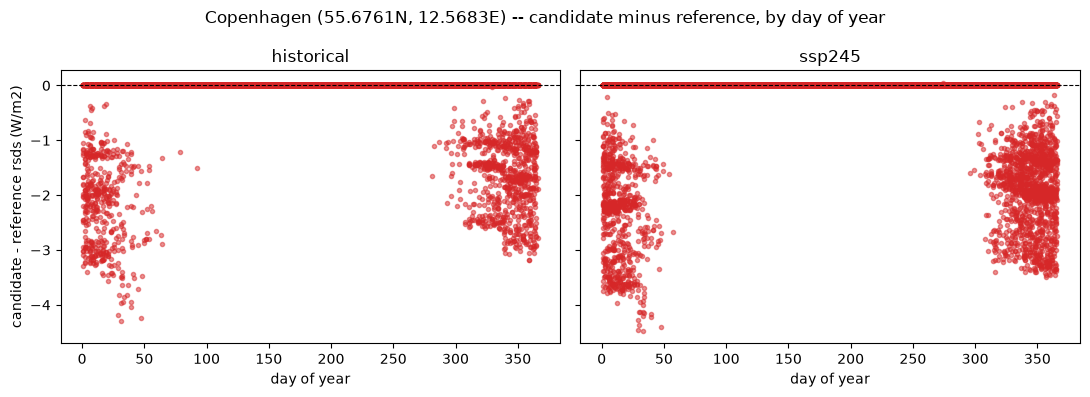

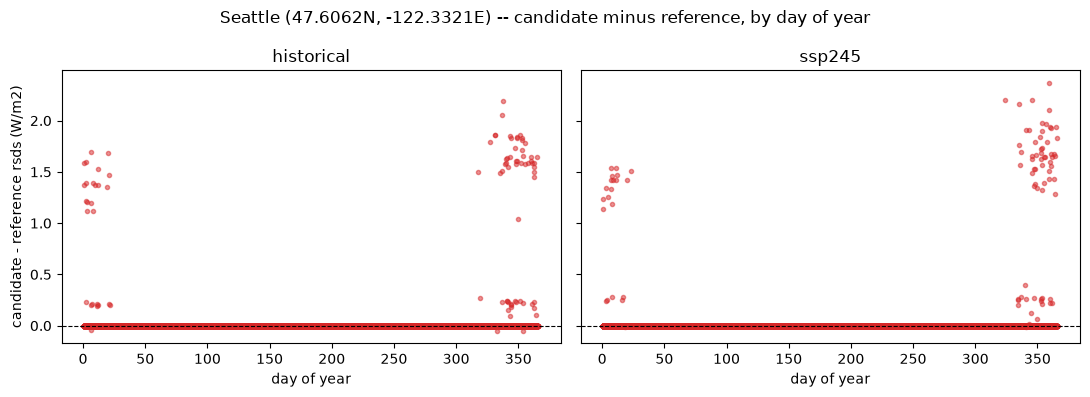

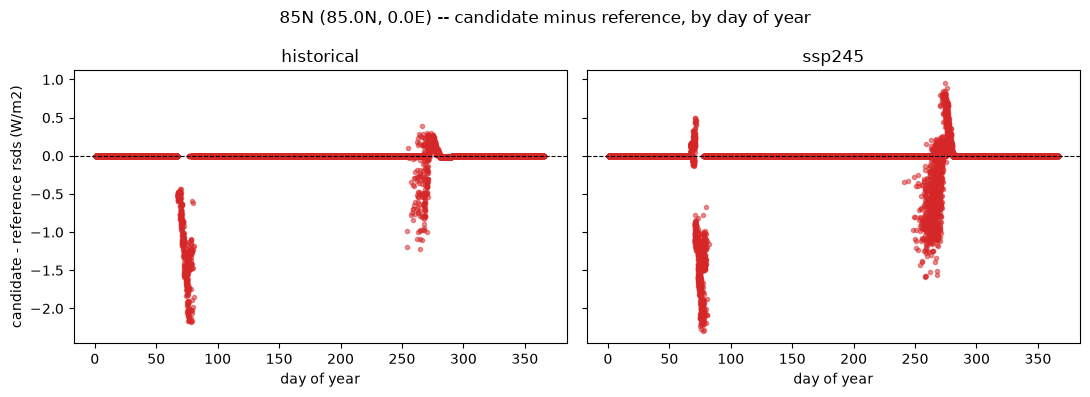

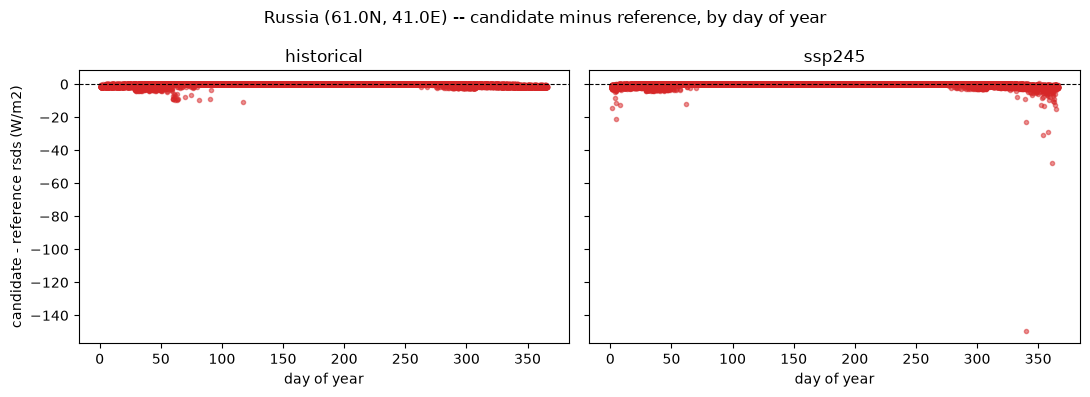

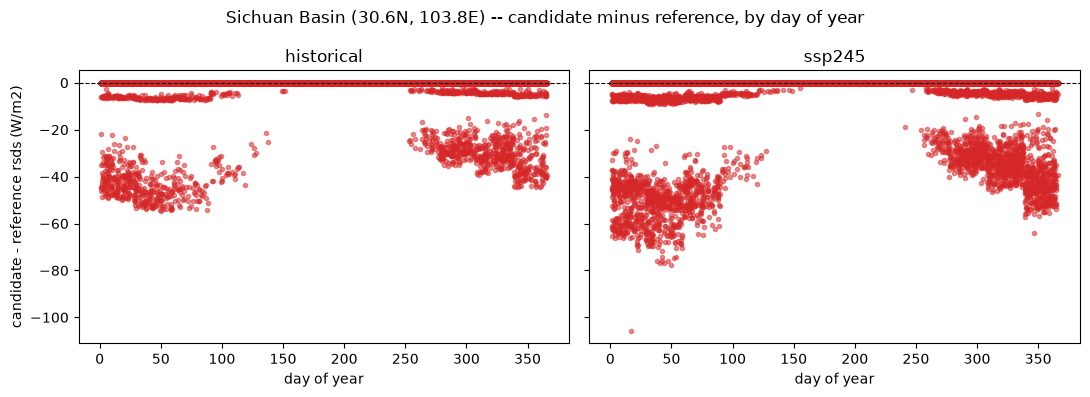

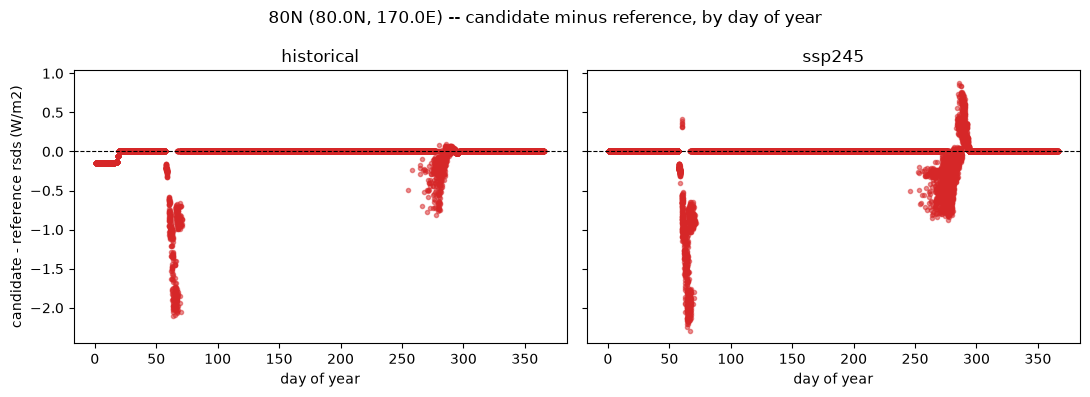

In [35]:
for name, (pt_lat, pt_lon) in POINTS.items():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, scenario in zip(axes, SCENARIOS):
        if ("reference", scenario) not in data or ("candidate", scenario) not in data:
            continue
        ref_pt = data[("reference", scenario)].sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
        cand_pt = data[("candidate", scenario)].sel(lat=pt_lat, lon=pt_lon, method="nearest").load()
        delta_pt = cand_pt - ref_pt
        ax.plot(
            delta_pt["time.dayofyear"],
            delta_pt,
            "o",
            color="tab:red",
            markersize=3,
            alpha=0.5,
        )
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlabel("day of year")
        ax.set_title(scenario)
    axes[0].set_ylabel("candidate - reference rsds (W/m2)")
    fig.suptitle(f"{name} ({pt_lat}N, {pt_lon}E) -- candidate minus reference, by day of year")
    plt.tight_layout()
    plt.show()

## Evaluation 2: annual outliers vs the ERA5 observational record

`flag_outliers` against the cached day-of-year ERA5 thresholds, collapsed to a single annual bound the same way production's `annual_outlier_flag` does. Also ERA5-fine-grid-only, same reason as Evaluation 1 -- `data` only, not `data_coarse`.


In [36]:
combined = xr.open_zarr(DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global.zarr")


def _split(ds, suffix):
    names = [v for v in ds.data_vars if v.endswith(suffix)]
    return ds[names].rename({v: v[: -len(suffix)] for v in names})


obs_max = _split(combined, "_max")
obs_min = _split(combined, "_min")
obs_max_std = _split(combined, "_max_std")
obs_min_std = _split(combined, "_min_std")

outlier_thresh_low, outlier_thresh_high = calculate_thresholds(
    obs_max, obs_min, obs_max_std, obs_min_std
)
outlier_thresh_low_annual = outlier_thresh_low.min(dim="dayofyear")[VAR]
outlier_thresh_high_annual = outlier_thresh_high.max(dim="dayofyear")[VAR]

/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


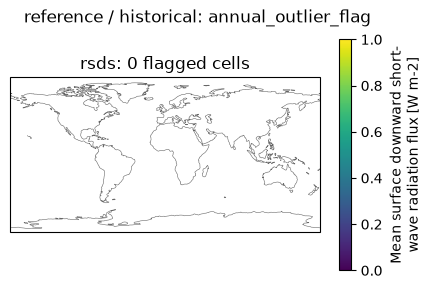

/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(


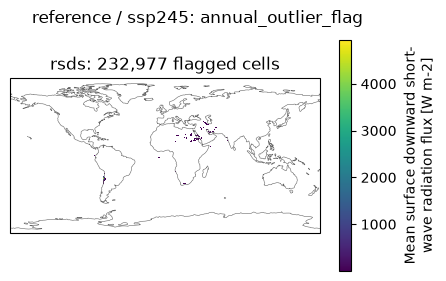

/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


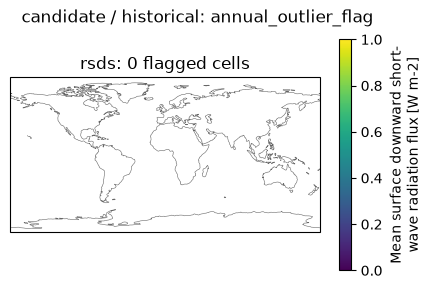

/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/Users/clairezarakas/Documents/science/srm-downscaling/.venv/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(


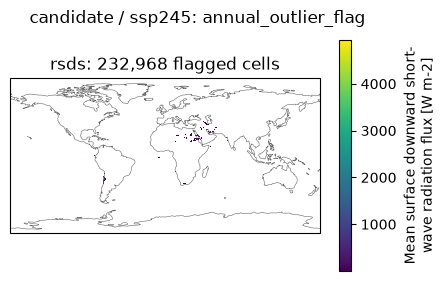

In [39]:
annual_outlier_flag = {}
for (label, scenario), da in data.items():
    flag = flag_outliers(
        da=da,
        outlier_thresh_low=outlier_thresh_low_annual,
        outlier_thresh_high=outlier_thresh_high_annual,
        timescale="annual",
    )
    flag_count = flag.sum(dim="time").load()
    annual_outlier_flag[(label, scenario)] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario}: annual_outlier_flag")
    plt.show()

In [40]:
annual_outlier_summary = pd.DataFrame(
    {
        f"{label}/{scenario}": summarize_flag_count(
            count, n_time=data[(label, scenario)].sizes["time"]
        )
        for (label, scenario), count in annual_outlier_flag.items()
    }
).T
annual_outlier_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
reference/historical,0.0,0.000000,0.000000
reference/ssp245,232977.0,0.000723,0.001019
candidate/historical,0.0,0.000000,0.000000
candidate/ssp245,232968.0,0.000723,0.001019


## Bonus check: global plausible-range exceedances

`flag_rsds_above_max` above only bounds the *high* side, and only applies to the fine-grid downscaled output. `flag_global_exceedances` (against `VAR_SPATIAL_RANGES["rsds"]`, min 0-100 W/m2) checks a fixed numeric range rather than comparing against another grid, so it's the one check here that runs on **both** `data` (downscaled) and `data_coarse` (debiased_coarse) -- relevant because a near-zero-climatology threshold change is exactly the kind of thing that can produce implausible or negative values, not just spikes, and could show up at either stage.


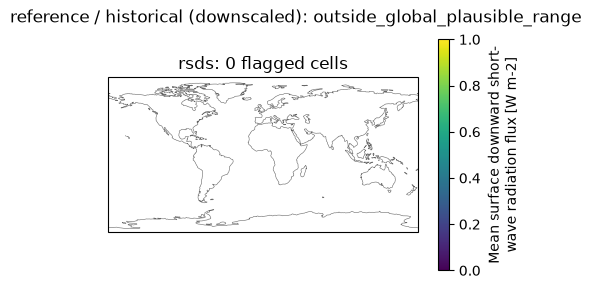

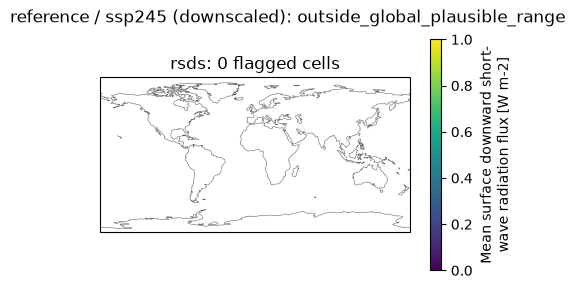

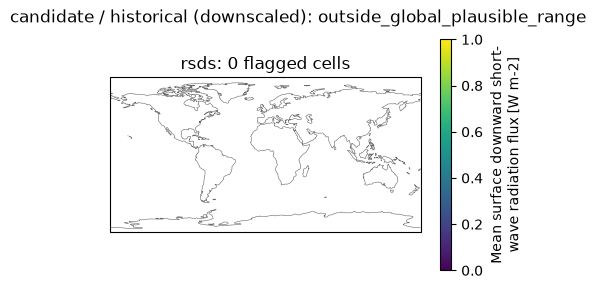

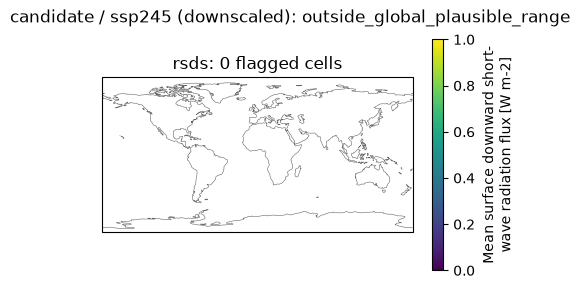

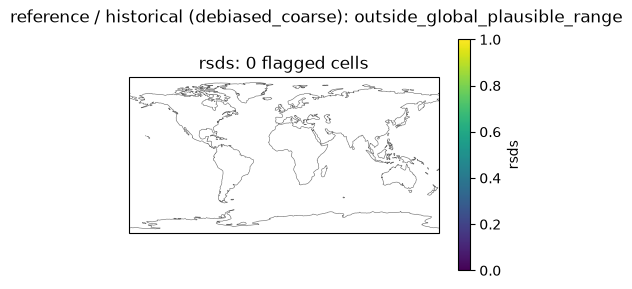

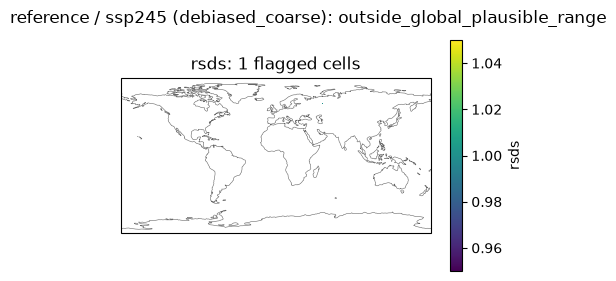

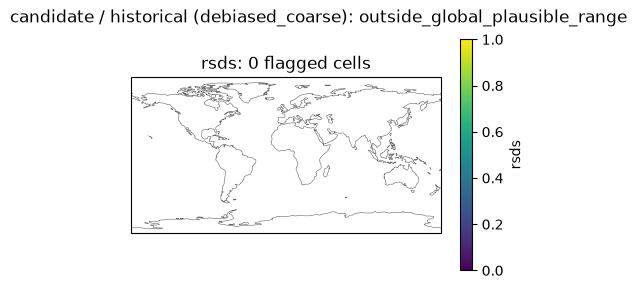

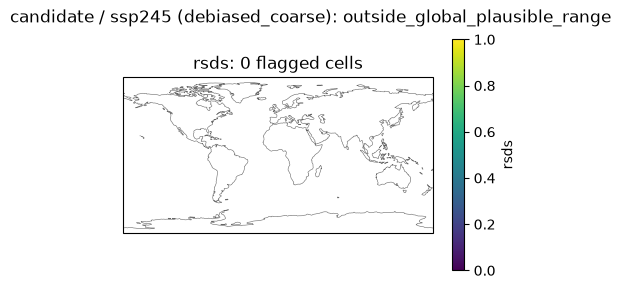

In [41]:
global_exceedance_flag = {}
for (label, scenario), da in data.items():
    flag = flag_global_exceedances(da=da, var=VAR)
    flag_count = flag.sum(dim="time").load()
    global_exceedance_flag[(label, scenario, "downscaled")] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario} (downscaled): outside_global_plausible_range")
    plt.show()

for (label, scenario), da in data_coarse.items():
    flag = flag_global_exceedances(da=da, var=VAR)
    flag_count = flag.sum(dim="time").load()
    global_exceedance_flag[(label, scenario, "debiased_coarse")] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario} (debiased_coarse): outside_global_plausible_range")
    plt.show()

In [42]:
def _n_time_for(label, scenario, source):
    return (data if source == "downscaled" else data_coarse)[(label, scenario)].sizes["time"]


global_exceedance_summary = pd.DataFrame(
    {
        f"{label}/{scenario}/{source}": summarize_flag_count(
            count, n_time=_n_time_for(label, scenario, source)
        )
        for (label, scenario, source), count in global_exceedance_flag.items()
    }
).T
global_exceedance_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
reference/historical/downscaled,0.0,0.000000e+00,0.000000e+00
reference/ssp245/downscaled,0.0,0.000000e+00,0.000000e+00
candidate/historical/downscaled,0.0,0.000000e+00,0.000000e+00
candidate/ssp245/downscaled,0.0,0.000000e+00,0.000000e+00
reference/historical/debiased_coarse,0.0,0.000000e+00,0.000000e+00
reference/ssp245/debiased_coarse,1.0,5.825063e-08,4.620870e-08
candidate/historical/debiased_coarse,0.0,0.000000e+00,0.000000e+00
candidate/ssp245/debiased_coarse,0.0,0.000000e+00,0.000000e+00


## Evaluation 3: trend distortion, historical → SSP245 (single ensemble member)

Reuses production's scenario-intercomparison distortion check: `calculate_ensemble_mean_deltas` (coarsens the downscaled output back to native GCM resolution and compares its historical→SSP245 delta against the same delta computed on the raw, undebiased GCM output) feeding `calculate_distortion_flags` (magnitude/percent distortion) and `sign_flip_mask` (does debiasing+downscaling flip the sign of the implied change). Uses `SCENARIO_COMPARISONS["ssp245_hist"]`'s time slices (historical 1978-2014 vs. SSP245 2065-2084) and `TREND_VARIABLE_SETTINGS["rsds"]`'s tolerances, both already tuned for this comparison in production.


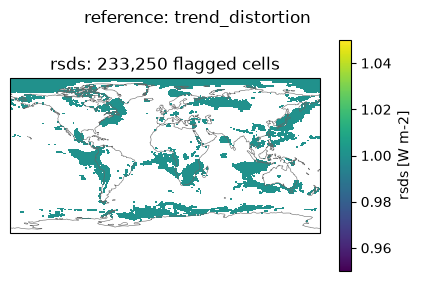

ConnectionError: Connection to scheduler closed before gather completed (scheduler recv ended: io error: IO error: Connection reset by peer (os error 54)).

In [52]:
comparison = SCENARIO_COMPARISONS["ssp245_hist"]
settings = TREND_VARIABLE_SETTINGS[VAR]

trend_distortion_flag_fine = {}
flipped_sign_flag_fine = {}

for label in LABELS:
    if not (
        availability[label]["historical"]["downscaled"]
        and availability[label]["ssp245"]["downscaled"]
    ):
        print(f"skipping {label}: missing historical and/or ssp245 rsds output")
        continue

    tag_hist = f"{GCM}_{VAR}_historical_{ENSEMBLE_BY_SCENARIO['historical']}_{METHOD}"
    tag_ssp = f"{GCM}_{VAR}_ssp245_{ENSEMBLE_BY_SCENARIO['ssp245']}_{METHOD}"

    delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, delta_ds = (
        calculate_ensemble_mean_deltas(
            variable=VAR,
            tags_scenario1=[tag_hist],
            tags_scenario2=[tag_ssp],
            gcm=GCM,
            scenario1=comparison["scenario1"],
            scenario2=comparison["scenario2"],
            scenario1_time_slice=comparison["scenario1_time_slice"],
            scenario2_time_slice=comparison["scenario2_time_slice"],
            trees={GCM: trees[label]},
        )
    )

    distortion_absolute = delta_ds_coarse - delta_raw
    distortion_pct = delta_ds_coarse_pct - delta_raw_pct

    trend_distortion_flag = calculate_distortion_flags(
        distortion_absolute=distortion_absolute * settings["scale"],
        distortion_pct=distortion_pct,
        tolerance_absolute=settings["abs_tol"],
        tolerance_pct=settings["pct_tol"],
    )
    flipped_sign_flag = sign_flip_mask(
        delta_ds_coarse * settings["scale"],
        delta_raw * settings["scale"],
        threshold=settings["sign_flip"],
    )

    trend_distortion_flag_fine[label] = (
        interpolate_coarse_to_fine_grid(
            da_coarse_to_regrid=trend_distortion_flag.astype("float32"), da_fine_grid=delta_ds
        )
        > 0
    )
    flipped_sign_flag_fine[label] = (
        interpolate_coarse_to_fine_grid(
            da_coarse_to_regrid=flipped_sign_flag.astype("float32"), da_fine_grid=delta_ds
        )
        > 0
    )

    plot_flags(flags=trend_distortion_flag_fine[label], time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label}: trend_distortion")
    plt.show()

    plot_flags(flags=flipped_sign_flag_fine[label], time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label}: flipped_sign")
    plt.show()

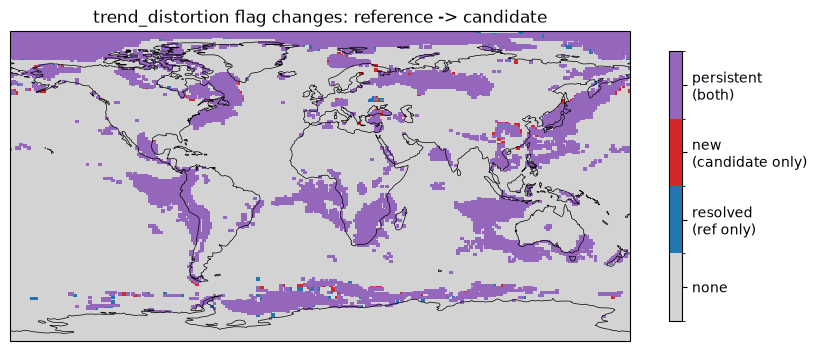

new flags (candidate only):       3291 cells
resolved flags (reference only):  2557 cells
persistent flags (both):          230693 cells


In [44]:
new_trend_flags = trend_distortion_flag_fine["candidate"] & ~trend_distortion_flag_fine["reference"]
resolved_trend_flags = (
    trend_distortion_flag_fine["reference"] & ~trend_distortion_flag_fine["candidate"]
)
persistent_trend_flags = (
    trend_distortion_flag_fine["reference"] & trend_distortion_flag_fine["candidate"]
)

# 0 = neither, 1 = resolved (reference only), 2 = new (candidate only), 3 = persistent (both)
category = xr.zeros_like(trend_distortion_flag_fine["reference"], dtype="int8")
category = category.where(~resolved_trend_flags, 1)
category = category.where(~new_trend_flags, 2)
category = category.where(~persistent_trend_flags, 3)

cmap = mcolors.ListedColormap(["lightgrey", "tab:blue", "tab:red", "tab:purple"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw=dict(projection=ccrs.PlateCarree()))
im = category.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
)
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels(
    ["none", "resolved\n(ref only)", "new\n(candidate only)", "persistent\n(both)"]
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_title("trend_distortion flag changes: reference -> candidate")
plt.show()

n_new = int(new_trend_flags.sum())
n_resolved = int(resolved_trend_flags.sum())
n_persistent = int(persistent_trend_flags.sum())
print(f"new flags (candidate only):       {n_new} cells")
print(f"resolved flags (reference only):  {n_resolved} cells")
print(f"persistent flags (both):          {n_persistent} cells")

In [45]:
trend_summary = pd.DataFrame(
    {
        **{
            f"{label}/trend_distortion": summarize_flag(flag)
            for label, flag in trend_distortion_flag_fine.items()
        },
        **{
            f"{label}/flipped_sign": summarize_flag(flag)
            for label, flag in flipped_sign_flag_fine.items()
        },
    }
).T
trend_summary

,flagged_cells,pct_flagged,area_weighted_pct
reference/trend_distortion,233250.0,22.465904,19.391008
candidate/trend_distortion,233984.0,22.536600,19.542707
reference/flipped_sign,2838.0,0.273347,0.388618
candidate/flipped_sign,2838.0,0.273347,0.388618


## Evaluation 4: historical mean bias vs. ERA5 observations

Everything above either checks internal plausibility (value ranges, trend distortion) or diffs branches against each other -- none of it compares the downscaled output to observations directly. This adds that basic sanity check: for each branch's historical run, how far off is the time-mean `rsds` from ERA5's time-mean over the same period, on the shared fine grid (`downscaled - obs`, same units as `rsds`)?

Deliberately kept to raw bias rather than percent bias. Percent bias divides by the observed mean, which blows up at exactly the near-zero-climatology (polar-night) cells the darkday threshold fix targets -- it would just reproduce the thing being investigated rather than diagnose it. Grid match between the downscaled output and ERA5 is asserted rather than assumed.


In [46]:
obs_fine = catalog.get("ERA5").to_xarray()[VAR]

historical_bias = {}
for label in LABELS:
    if not availability[label]["historical"]["downscaled"]:
        print(f"skipping {label}: no historical downscaled output")
        continue

    da_hist = data[(label, "historical")]
    common_time = da_hist.indexes["time"].intersection(obs_fine.indexes["time"])
    da_mean = da_hist.sel(time=common_time).mean(dim="time").compute()
    obs_mean = obs_fine.sel(time=common_time).mean(dim="time").compute()

    assert (
        da_mean.sizes["lat"] == obs_mean.sizes["lat"]
        and da_mean.sizes["lon"] == obs_mean.sizes["lon"]
    ), (
        f"{label}: grid mismatch between downscaled output ({da_mean.sizes}) and ERA5 obs ({obs_mean.sizes}) -- regrid needed, don't trust a silent coordinate-intersection result"
    )

    historical_bias[label] = da_mean - obs_mean
    print(f"{label}: {len(common_time)} overlapping historical days vs. ERA5")

reference: 13514 overlapping historical days vs. ERA5
candidate: 13514 overlapping historical days vs. ERA5


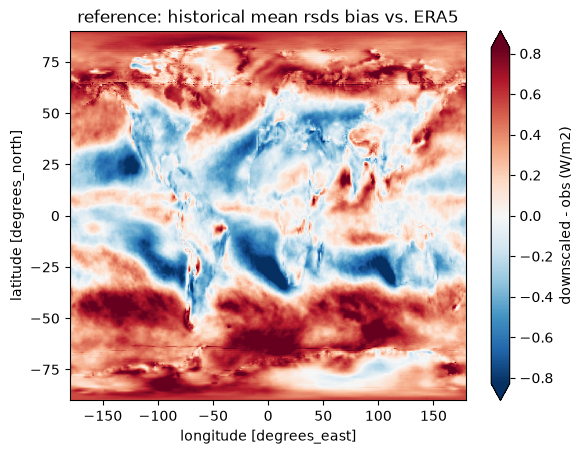

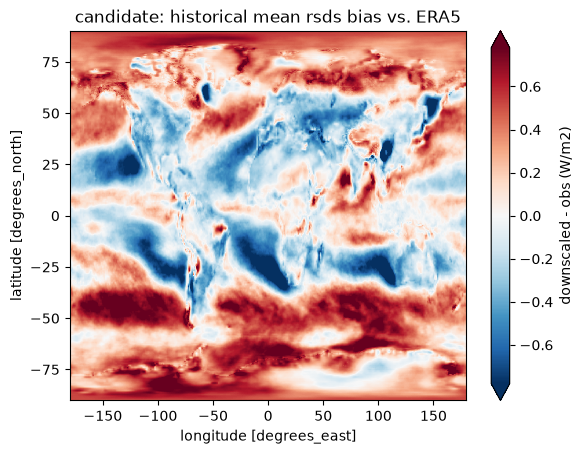

In [ ]:
for label, bias in historical_bias.items():
    bias.plot(
        cmap=plt.cm.RdBu_r, center=0, robust=True, cbar_kwargs={"label": "downscaled - obs (W/m2)"}
    )
    plt.title(f"{label}: historical mean rsds bias vs. ERA5")
    plt.show()

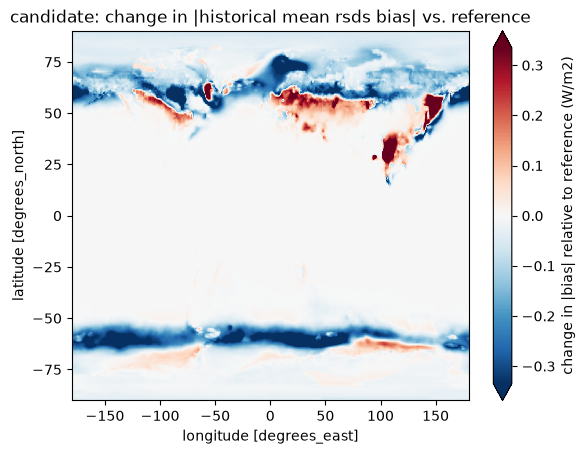

In [47]:
if "reference" in historical_bias and "candidate" in historical_bias:
    (np.abs(historical_bias["candidate"]) - np.abs(historical_bias["reference"])).plot(
        cmap=plt.cm.RdBu_r,
        center=0,
        robust=True,
        cbar_kwargs={"label": "change in |bias| relative to reference (W/m2)"},
    )
    plt.title("candidate: change in |historical mean rsds bias| vs. reference")
    plt.show()

In [ ]:
def summarize_bias(bias: xr.DataArray) -> dict:
    weights = area_weights(bias["lat"])
    return {
        "mean_bias": float(bias.mean(skipna=True)),
        "mean_abs_bias": float(np.abs(bias).mean(skipna=True)),
        "area_weighted_mean_bias": float(bias.weighted(weights).mean(skipna=True)),
        "area_weighted_mean_abs_bias": float(np.abs(bias).weighted(weights).mean(skipna=True)),
    }


historical_bias_summary = pd.DataFrame(
    {label: summarize_bias(bias) for label, bias in historical_bias.items()}
).T
historical_bias_summary

,mean_bias,mean_abs_bias,area_weighted_mean_bias,area_weighted_mean_abs_bias
reference,0.180476,0.353733,0.07299,0.312692
candidate,0.132748,0.325375,0.03710,0.296124


## Side-by-side summary

All five checks, one table per branch/scenario/comparison. Lower is better everywhere except `historical_bias_vs_obs`, where the sign is informative (positive = branch too high vs. ERA5) and `mean_bias`/`area_weighted_mean_bias` can cancel across sign -- see `mean_abs_bias` for overall magnitude.


In [ ]:
all_summary = pd.concat(
    {
        "debiased_coarse_diff": debiased_coarse_summary,
        "rsds_max_exceeded": rsds_max_summary,
        "annual_outlier": annual_outlier_summary,
        "outside_global_plausible_range": global_exceedance_summary,
        "trend_distortion_or_sign_flip": trend_summary,
    },
    names=["check", "branch/scenario"],
)
all_summary

max_abs_diff  \
check                          branch/scenario                                      
debiased_coarse_diff           historical                              131.561829   
                               ssp245                                 1277.659546   
rsds_max_exceeded              reference/historical                           NaN   
                               reference/ssp245                               NaN   
                               candidate/historical                           NaN   
                               candidate/ssp245                               NaN   
annual_outlier                 reference/historical                           NaN   
                               reference/ssp245                               NaN   
                               candidate/historical                           NaN   
                               candidate/ssp245                               NaN   
outside_global_plausible_range reference/historical/downscaled                NaN   
                               reference/ssp245/downscaled                    NaN   
                               candidate/historical/downscaled                NaN   
                               candidate/ssp245/downscaled                    NaN   
                               reference/historical/debiased_coarse           NaN   
                               reference/ssp245/debiased_coarse               NaN   
                               candidate/historical/debiased_coarse           NaN   
                               candidate/ssp245/debiased_coarse               NaN   
trend_distortion_or_sign_flip  reference/trend_distortion                     NaN   
                               candidate/trend_distortion                     NaN   
                               reference/flipped_sign                         NaN   
                               candidate/flipped_sign                         NaN   

                                                                     mean_abs_diff  \
check                          branch/scenario                                       
debiased_coarse_diff           historical                                 0.062297   
                               ssp245                                     0.053719   
rsds_max_exceeded              reference/historical                            NaN   
                               reference/ssp245                                NaN   
                               candidate/historical                            NaN   
                               candidate/ssp245                                NaN   
annual_outlier                 reference/historical                            NaN   
                               reference/ssp245                                NaN   
                               candidate/historical                            NaN   
                               candidate/ssp245                                NaN   
outside_global_plausible_range reference/historical/downscaled                 NaN   
                               reference/ssp245/downscaled                     NaN   
                               candidate/historical/downscaled                 NaN   
                               candidate/ssp245/downscaled                     NaN   
                               reference/historical/debiased_coarse            NaN   
                               reference/ssp245/debiased_coarse                NaN   
                               candidate/historical/debiased_coarse            NaN   
                               candidate/ssp245/debiased_coarse                NaN   
trend_distortion_or_sign_flip  reference/trend_distortion                      NaN   
                               candidate/trend_distortion                      NaN   
                               reference/flipped_sign                          NaN   
                               candidate/flipped_s

## Other evaluations to consider

Not implemented here — worth adding if the checks above come back clean or inconclusive for characterizing the darkday threshold fix (the earlier PR #664 regional investigation found exactly this: `pct_implausible_days`-style checks were 0% for every method and weren't a useful discriminator, while more targeted diagnostics were):

- **Temporal-variance ratio vs. ERA5** at high-latitude / low-climatology cells specifically: does thresholding dark days flatten or otherwise distort day-to-day variability there relative to ERA5, beyond what the mean-bias check above can show?
- **Override-magnitude diagnostic**: how often the dark-day threshold actually triggers, globally by latitude band -- explains *where and how much* the fix changes the debiasing step, which the point comparisons above only sample at four locations.
- **Zonal-mean seasonal-cycle drift**: a cheap sanity check that the threshold change doesn't shift the coarse-scale climatology outside the polar-night cells it's meant to target.


## Single point deep dive: QDMSD downscaled vs. raw GCM vs. ERA5 obs, 2010-2020

- **raw GCM**: unprocessed `CESM2-WACCM` `rsds` (native coarse grid, nearest point to Beijing) -- historical (`r3i1p1f1`) stitched to SSP245 (`003`), the same members used everywhere else in this notebook.
- **ERA5 obs**: observational record (fine grid, nearest point) -- historical only, no SSP245 analog exists.
- **QDMSD downscaled**: `reference` and `candidate`'s final fine-grid output at the same point.

This shows whether `darkday-threshold-rsds-qdm` moves the downscaled output closer to or further from both the raw driving signal and observations over a multi-year window, rather than a single day-of-year snapshot.


In [50]:
PT_LAT, PT_LON = [80, 170]
PT_YEARS = slice("2005-01-01", "2020-12-31")

raw_hist_beijing = (
    catalog.get(GCM)
    .to_xarray()["historical"][VAR]
    .sel(ensemble_member=ENSEMBLE_BY_SCENARIO["historical"])
    .sel(lat=PT_LAT, lon=PT_LON, method="nearest")
    .sel(time=PT_YEARS)
)
raw_ssp_beijing = (
    catalog.get(GCM)
    .to_xarray()["ssp245"][VAR]
    .sel(ensemble_member=ENSEMBLE_BY_SCENARIO["ssp245"])
    .sel(lat=PT_LAT, lon=PT_LON, method="nearest")
    .sel(time=PT_YEARS)
)
raw_gcm_beijing = xr.concat([raw_hist_beijing, raw_ssp_beijing], dim="time").sortby("time").load()

# Independent of the Evaluation 4 `obs_fine` variable above -- self-contained so this section
# runs regardless of whether Evaluation 4 has been executed.
obs_beijing = (
    catalog.get("ERA5")
    .to_xarray()[VAR]
    .sel(lat=PT_LAT, lon=PT_LON, method="nearest")
    .sel(time=PT_YEARS)
    .load()
)

downscaled_beijing = {}
for label in LABELS:
    parts = [
        data[(label, scenario)].sel(lat=PT_LAT, lon=PT_LON, method="nearest").sel(time=PT_YEARS)
        for scenario in SCENARIOS
        if (label, scenario) in data
    ]
    if parts:
        downscaled_beijing[label] = xr.concat(parts, dim="time").sortby("time").load()

print(
    "raw GCM:",
    dict(raw_gcm_beijing.sizes),
    "| obs:",
    dict(obs_beijing.sizes),
    "| downscaled:",
    {k: dict(v.sizes) for k, v in downscaled_beijing.items()},
)

/var/folders/bx/my3tq4_53k10360h4nsb6k1c0000gn/T/ipykernel_32553/1427761428.py:6: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  raw_gcm_beijing = xr.concat([raw_hist_beijing, raw_ssp_beijing], dim="time").sortby("time").load()


raw GCM: {'time': 5844} | obs: {'time': 3652} | downscaled: {'reference': {'time': 5844}, 'candidate': {'time': 5844}}


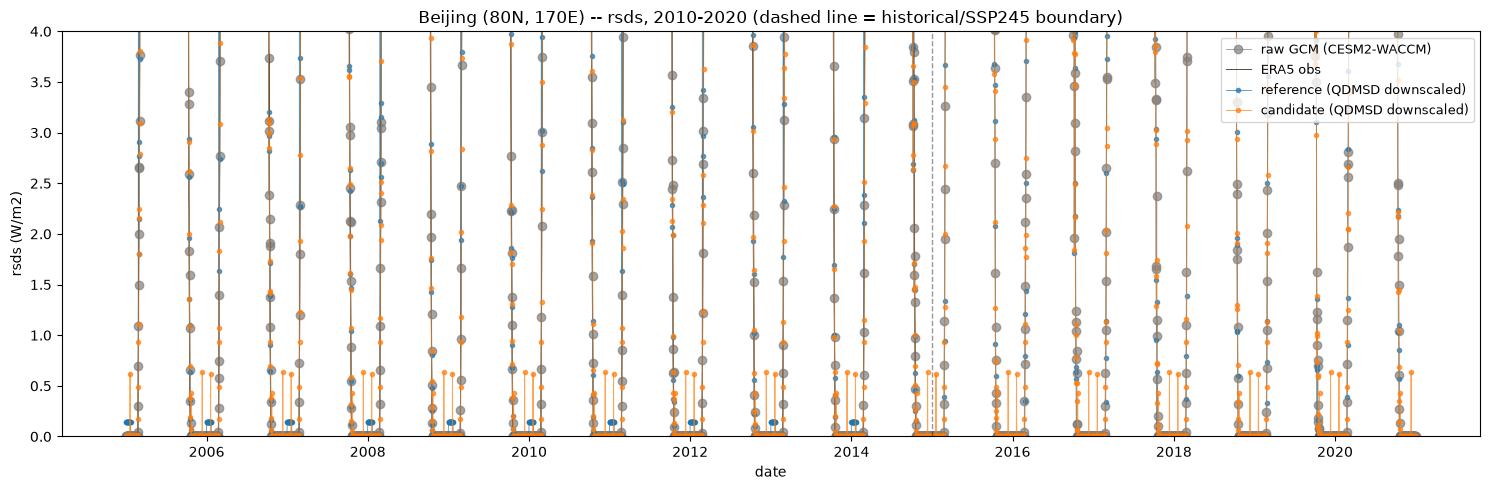

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    raw_gcm_beijing["time"],
    raw_gcm_beijing,
    color="grey",
    lw=0.7,
    alpha=0.7,
    label=f"raw GCM ({GCM})",
    marker="o",
    linestyle="-",
)
ax.plot(obs_beijing["time"], obs_beijing, color="black", lw=0.7, alpha=0.7, label="ERA5 obs")
for label, da in downscaled_beijing.items():
    ax.plot(
        da["time"],
        da,
        color=LABEL_COLORS[label],
        lw=0.7,
        alpha=0.7,
        label=f"{label} (QDMSD downscaled)",
        marker=".",
        linestyle="-",
    )
ax.axvline(pd.Timestamp("2015-01-01"), color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_xlabel("date")
ax.set_ylabel("rsds (W/m2)")
ax.set_title(
    f"Beijing ({PT_LAT}N, {PT_LON}E) -- rsds, 2010-2020 (dashed line = historical/SSP245 boundary)"
)
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim([0, 4])
plt.tight_layout()
plt.show()

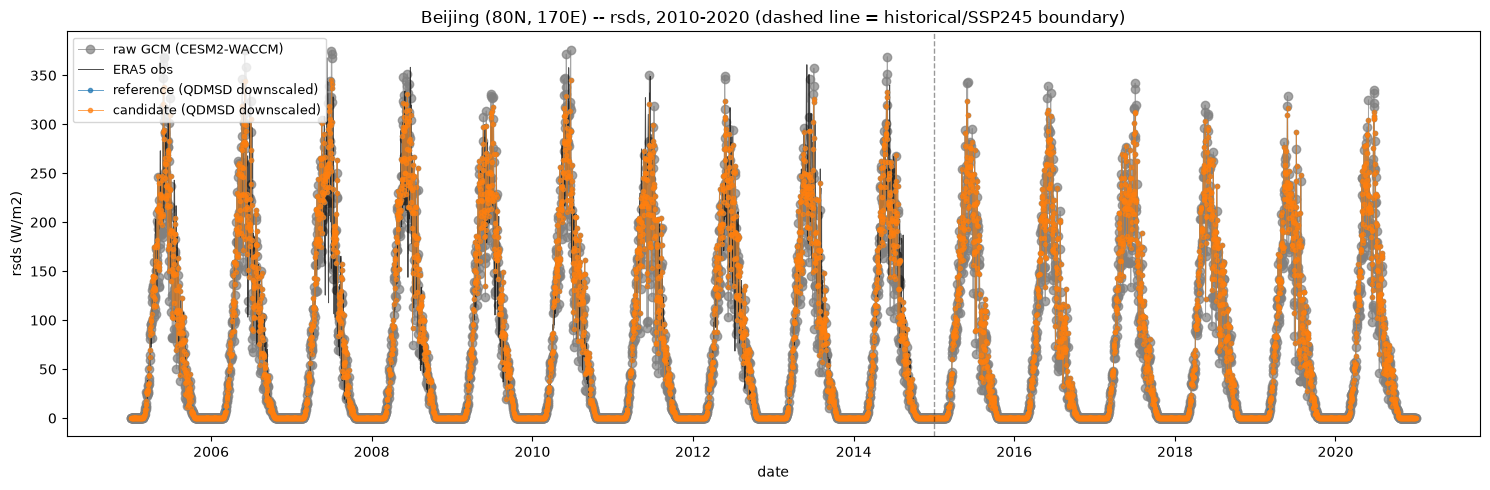

In [53]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    raw_gcm_beijing["time"],
    raw_gcm_beijing,
    color="grey",
    lw=0.7,
    alpha=0.7,
    label=f"raw GCM ({GCM})",
    marker="o",
    linestyle="-",
)
ax.plot(obs_beijing["time"], obs_beijing, color="black", lw=0.7, alpha=0.7, label="ERA5 obs")
for label, da in downscaled_beijing.items():
    ax.plot(
        da["time"],
        da,
        color=LABEL_COLORS[label],
        lw=0.7,
        alpha=0.7,
        label=f"{label} (QDMSD downscaled)",
        marker=".",
        linestyle="-",
    )
ax.axvline(pd.Timestamp("2015-01-01"), color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_xlabel("date")
ax.set_ylabel("rsds (W/m2)")
ax.set_title(
    f"Beijing ({PT_LAT}N, {PT_LON}E) -- rsds, 2010-2020 (dashed line = historical/SSP245 boundary)"
)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

(0.0, 1.0)

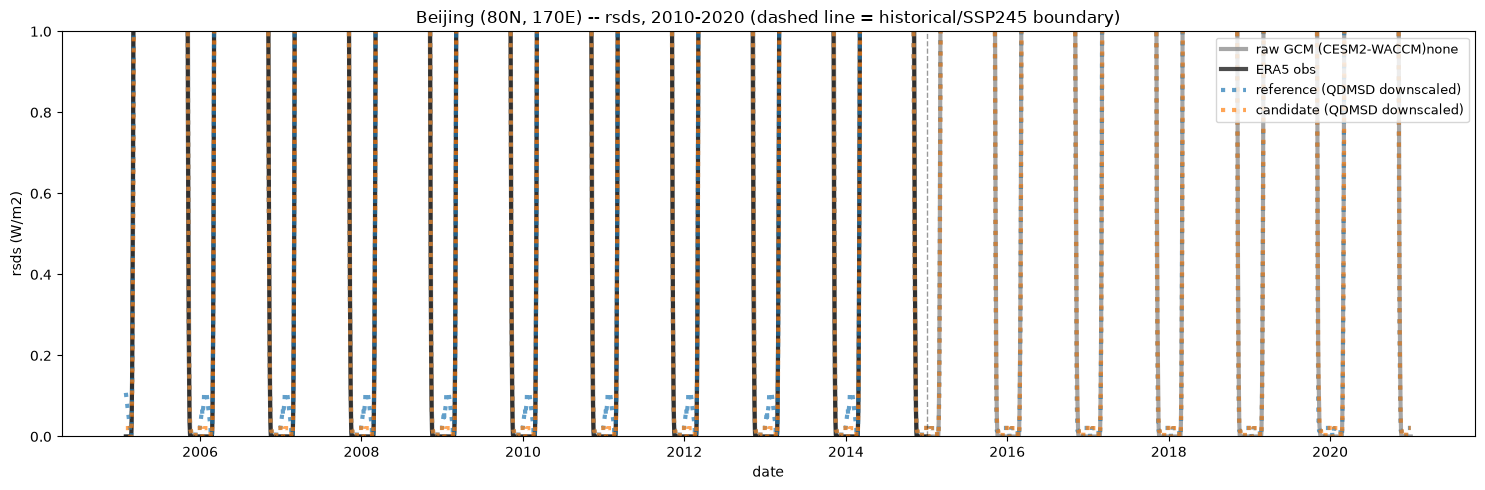

In [57]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    raw_gcm_beijing["time"],
    raw_gcm_beijing.rolling(time=30).mean(),
    color="grey",
    lw=3,
    alpha=0.7,
    label=f"raw GCM ({GCM})none",
)
ax.plot(
    obs_beijing["time"],
    obs_beijing.rolling(time=30).mean(),
    color="black",
    lw=3,
    alpha=0.7,
    label="ERA5 obs",
)
for label, da in downscaled_beijing.items():
    ax.plot(
        da["time"],
        da.rolling(time=30).mean(),
        color=LABEL_COLORS[label],
        lw=3,
        alpha=0.7,
        label=f"{label} (QDMSD downscaled)",
        linestyle=":",
    )
ax.axvline(pd.Timestamp("2015-01-01"), color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_xlabel("date")
ax.set_ylabel("rsds (W/m2)")
ax.set_title(
    f"Beijing ({PT_LAT}N, {PT_LON}E) -- rsds, 2010-2020 (dashed line = historical/SSP245 boundary)"
)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
ax.set_ylim([0, 1])